# ISEN 427 Final Report
### Fletcher Newman | April 7th, 2025

In [4]:
import pandas as pd
import pymc as pm
import numpy as np
import arviz as az
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from scipy.special import expit as logistic
import xarray as xr
import tensorflow as tf
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split


az.style.use("arviz-darkgrid")

In [5]:
# Load the data in
ump1_orig = pd.read_csv('https://raw.githubusercontent.com/lekhapriya/ISEN_427-627_Project_2025/refs/heads/main/Umpire_1.csv')

In [6]:
def clean_df(orig_df):
    """
    Pitch types:
        ['SI' 'AB' 'SL' 'FC' 'CH' 'CU' 'FF' 'FS' 'EP' 'KC' 'FO' 'KN' 'SC' 'ST'
         'SV' 'CS' 'FA']
    Handedness: R=1, L=0
    Description: 'ball': 0, 'called_strike': 1
    Error in decision: 'correct': 0, 'incorrect': 1
    """
    df = orig_df.copy()
    # Drop nulls
    df = df.dropna()

    # Map pitch types to binary columns
    unique_pt = df['pitch_type'].unique()
    fastballs = ['FF', 'FA', 'FT', 'SI', 'FC'] # 4 seam, 4 seam again, two seam, sinker, cutter
    changeups = ['CH', 'EP', 'FO', 'FS'] # Change, ephus, fork, split
    off_speed = ['SL', 'CU', 'ST', 'SV', 'CS'] # Slider, curve, sweeper, slurve, slow curve
    rare = ['KC', 'KN', 'SC'] # Knucle curve, knuckle ball, screwball
    # AB and AS are 'automatic ball/strike' so they are not included. This happens when something like a pitch clock violation occurs
    # Against the pitcher or the hitter

    # Create new binary columns
    df['fastball'] = df['pitch_type'].isin(fastballs).astype(int)
    df['changeup'] = df['pitch_type'].isin(changeups).astype(int)
    df['off_speed'] = df['pitch_type'].isin(off_speed).astype(int)
    df['rare'] = df['pitch_type'].isin(rare).astype(int)

    # Drop ptich_type column since it is not categorical
    df = df.drop(columns='pitch_type')

    # Same with error
    df['error_in_decision'] = df['error_in_decision'].map({'correct': 0, 'incorrect': 1})

    # Fix handedness
    df['stand'] = df['stand'].map({'R': 1, 'L': 0})
    df['p_throws'] = df['p_throws'].map({'R': 1, 'L': 0})

    df['description'] = df['description'].map({'ball': 0, 'called_strike': 1})


    # Max min scale the data to make coefficienst more interpretable
    columns_to_scale = df.drop(columns=['error_in_decision', 'fastball', 'changeup', 'off_speed', 'rare']).columns
    scaler = StandardScaler()
    df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

    return df


ump1 = clean_df(ump1_orig)

## I want to check the effects of:
1) Type of pitch (including velo and characteristics)
- pitch_type (binary for each type)

2) Count
- Balls, strikes, pitch_number, at_bat_number, description, most influential pitch type from 1

3) Important situaion
- delta_home_win_exp, delta_run_exp, home_score, away_score, on_3b/2/1

4) Pitch charactaristics
- plate_z, plate_x, release_speed, release_pos_x, release_pos_z, description, release_pos_y, pitch_location

5) Pitch Profile
- pfx_x, pfx_z, vx0, vy0, vz0, ax, ay, az

6) Dimentions of pitcher and hitter
- all_star_player, sz_bot, sz_top, stand, p_throws

### Random Sample of data (for now at least)

In [7]:
df, df_test, labels_train, labels_test = train_test_split(ump1.drop(columns='error_in_decision'), ump1['error_in_decision'], test_size=0.2, random_state=42)
df['error_in_decision'] = labels_train
df_test['error_in_decision'] = labels_test
# df = ump1[0:2000] # ump1.sample(n=200, random_state=42) # Only take a small amount so that the modeling doesn't take 5-ever
# df_test = ump1[2000:4000]
labels = np.array(df['error_in_decision'])
# outcomes_test = np.array(X_test['error_in_decision'])

# Init loocv dict to compare all models
loocv_ump1 = {}
model_accuracies = {}

In [8]:
# Create synthetic dataset
true_beta = -10
true_intercept = 0
true_p = 1 / (1+np.exp(-(true_intercept + true_beta*df['pitch_location'])))
true_outcomes = np.array((true_p > 0.5).astype(int))

# Example of bad prior
**Using normal distribution**

In [9]:
### https://www.pymc.io/projects/docs/en/stable/learn/core_notebooks/posterior_predictive.html
# Check prior for pitch_location beta

# Create synthetic dataset
true_beta = -10
true_intercept = 2
true_p = 1 / (1+np.exp(-(true_intercept + true_beta*df['pitch_location'])))
true_outcomes = np.array((true_p > 0.5).astype(int))

with pm.Model() as location_model:

    # Priors
    intercept = pm.Normal("intercept", mu=0, sigma=10)
    pitch_location = pm.Normal("pitch_location", mu=0, sigma=10)

    # Logistic transform
    # Makes predictors as a shared variable
    pred_pitch_location = pm.Data("pred_pitch_location", df['pitch_location'], dims="obs_id")
    p = pm.Deterministic("p", 1/(1+np.exp(-(intercept + pitch_location * pred_pitch_location))), dims="obs_id")

    # outcome
    outcome = pm.Bernoulli("outcome", p=p, observed=true_outcomes, dims="obs_id")

    idata = pm.sample_prior_predictive(draws=50, random_seed=42)

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


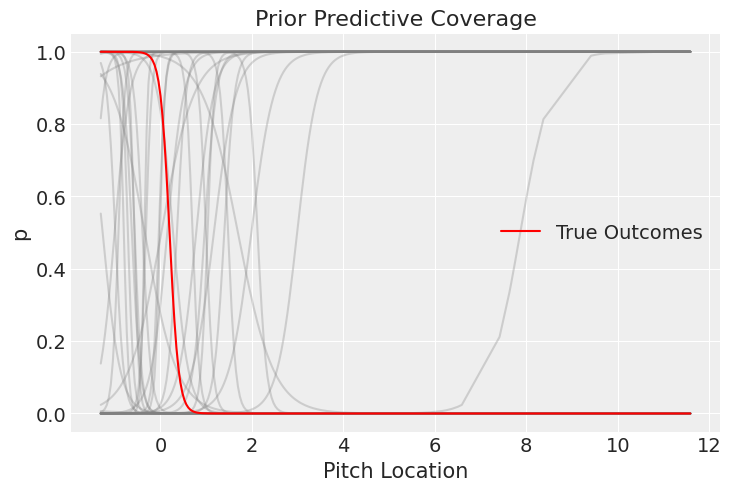

In [10]:
# Get the prior predictive probabilities

p_prior = idata.prior["p"].values  # shape: (draws, obs)

X_sorted_idx = np.argsort(df['pitch_location'])
X_sorted = df['pitch_location'].values[X_sorted_idx]
true_sorted = true_p.iloc[X_sorted_idx]

# p_prior_sorted = p_prior[:, X_sorted_idx]

for sig in idata.prior['p'].values[0]:
    # Sort data
    sig_sort = sig[X_sorted_idx]
    # Plot data
    plt.plot(X_sorted, sig_sort, color='gray', alpha=0.3)


# plt.plot(X_sorted, p_prior_sorted[0][0], color='dodgerblue')

plt.plot(X_sorted, true_sorted, color='red', label='True Outcomes', zorder=3)

plt.xlabel("Pitch Location")
plt.ylabel("p")
plt.title("Prior Predictive Coverage")
plt.legend()
plt.show()

This is bad data coverage, since the distributions are not all the same shape as the true (some go from 0 to 1 as pitch location increases instead of 1 to 0). This tells you that you must try a different prior. A negitive half normal will be tried next.

In [11]:
### https://www.pymc.io/projects/docs/en/stable/learn/core_notebooks/posterior_predictive.html
# Check prior for pitch_location beta

# Create synthetic dataset
# true_beta = -10
# true_intercept = 2
# true_p = 1 / (1+np.exp(-(true_intercept + true_beta*df['pitch_location'])))
# true_outcomes = np.array((true_p > 0.5).astype(int))

with pm.Model() as location_model_2:

    # Priors
    intercept = pm.Normal("intercept", mu=0, sigma=10)
    pitch_location = -pm.HalfNormal("pitch_location", sigma=10)

    # Logistic transform
    # Makes predictors as a shared variable
    pred_pitch_location = pm.Data("pred_pitch_location", df['pitch_location'], dims="obs_id")
    p = pm.Deterministic("p", 1/(1+np.exp(-(intercept + pitch_location * pred_pitch_location))), dims="obs_id")

    # outcome
    outcome = pm.Bernoulli("outcome", p=p, observed=true_outcomes, dims="obs_id")

    idata_2 = pm.sample_prior_predictive(draws=50, random_seed=42)


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


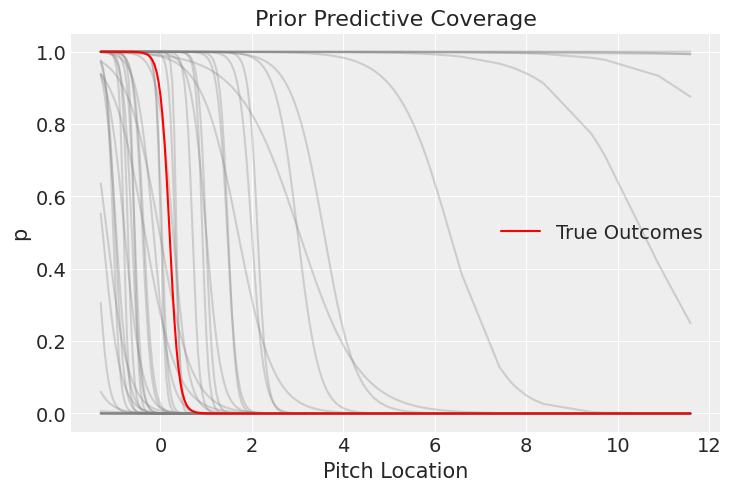

In [12]:
# Get the prior predictive probabilities

p_prior = idata_2.prior["p"].values  # shape: (draws, obs)

X_sorted_idx = np.argsort(df['pitch_location'])
X_sorted = df['pitch_location'].values[X_sorted_idx]
true_sorted = true_p.iloc[X_sorted_idx]

# p_prior_sorted = p_prior[:, X_sorted_idx]

for sig in idata_2.prior['p'].values[0]:
    # Sort data
    sig_sort = sig[X_sorted_idx]
    # Plot data
    plt.plot(X_sorted, sig_sort, color='gray', alpha=0.3)


# plt.plot(X_sorted, p_prior_sorted[0][0], color='dodgerblue')

plt.plot(X_sorted, true_sorted, color='red', label='True Outcomes', zorder=3)

plt.xlabel("Pitch Location")
plt.ylabel("p")
plt.title("Prior Predictive Coverage")
plt.legend()
plt.show()

Here, there is good 'data coverage', eg. the distributions have the same general shape as the true distibution even though they are not exactly the same.

### Real model using pitch location

Getting advi samples...


Output()

Tracing mean field...
Plotting posterior...


<Axes: title={'center': 'pitch_location'}>

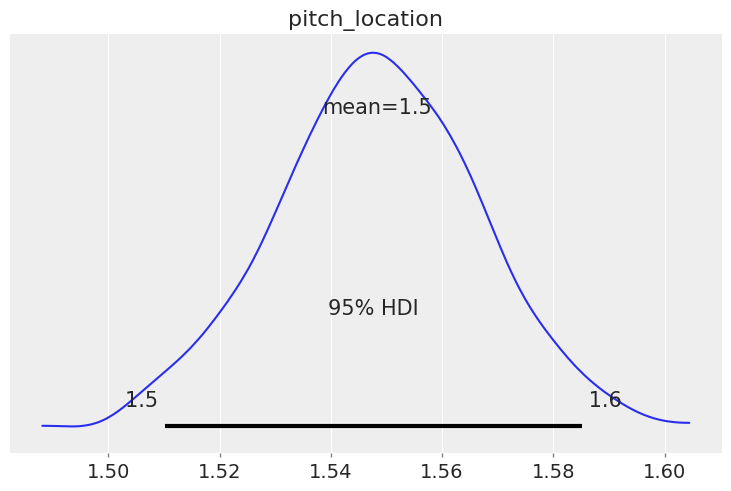

In [13]:
# Create real model, pitch_location
with pm.Model() as m_locaiton:
    # Priors
    intercept = pm.Normal("intercept", mu=0, sigma=10)
    pitch_location = pm.HalfNormal("pitch_location", sigma=10)

    # Likelihood
    mu = intercept - (pitch_location*df['pitch_location']) # minus pitch location since prior is suposed to be negitive half normal
    theta = pm.Deterministic('theta', pm.math.sigmoid(mu))
    y1 = pm.Bernoulli('y1', p=theta, observed=labels)

    # ELPD_LOO
    print("Getting advi samples...")
    mean_field = pm.fit(method='advi', obj_optimizer=pm.adagrad_window(learning_rate=1e-2))
    # idata1 = pm.sample(draws=1000, idata_kwargs={"log_likelihood":True})
    # idata1.extend(pm.sample_posterior_predictive(idata1))
    # loocv_ump1["m1"] = idata1

print("Tracing mean field...")
trace_location = mean_field.sample(1000)

# add to model comparision dict
loocv_ump1["locaiton"] = trace_location

print("Plotting posterior...")
az.plot_posterior(trace_location, var_names=["pitch_location"], hdi_prob=0.95)

**Make predictions to evaluate model**

**Get Accuracy**

In [14]:
# Init param samples
param_samples = {}

# Make predictions for each posterior sample
n_samples = len(trace_location.posterior['intercept'])
n_obs = len(df_test)

# Initialize predictions array
all_preds = np.zeros((n_samples, n_obs))

# Get samples from each param (generalized for any number of params)
for param in ['intercept', 'pitch_location']:
    param_samples[param] = trace_location.posterior[param].values.flatten()

# Make predictions
for i in range(n_samples):
  # Use df_test!
  mu = param_samples['intercept'][i] - (param_samples['pitch_location'][i]*df_test['pitch_location'])
  all_preds[i, :] = 1 / (1 + np.exp(-mu))  # sigmoid function

# Make predictions
y_pred_proba = all_preds.mean(axis=0)
y_pred = (y_pred_proba > 0.5).astype(int)

# Calculate accuracy
accuracy = np.mean(y_pred == df_test['error_in_decision'])
model_accuracies["location"] = accuracy

# print accuracy
print(f"Accuracy: {accuracy}")
print(f"Number of Category 0: {np.sum(y_pred == 0)}")
print(f"Number of Category 1: {np.sum(y_pred == 1)}")

Accuracy: 0.8702772963604852
Number of Category 0: 11540
Number of Category 1: 0


# 1) Type of pitch
- pitch_type (binary for each type)

## Check Priors

In [15]:
df['changeup']

,changeup
50283,0
19685,0
55425,0
14936,1
52744,0
...,...
54356,0
38158,0
860,0
15795,0


<ipython-input-16-857101bf0813>:68: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


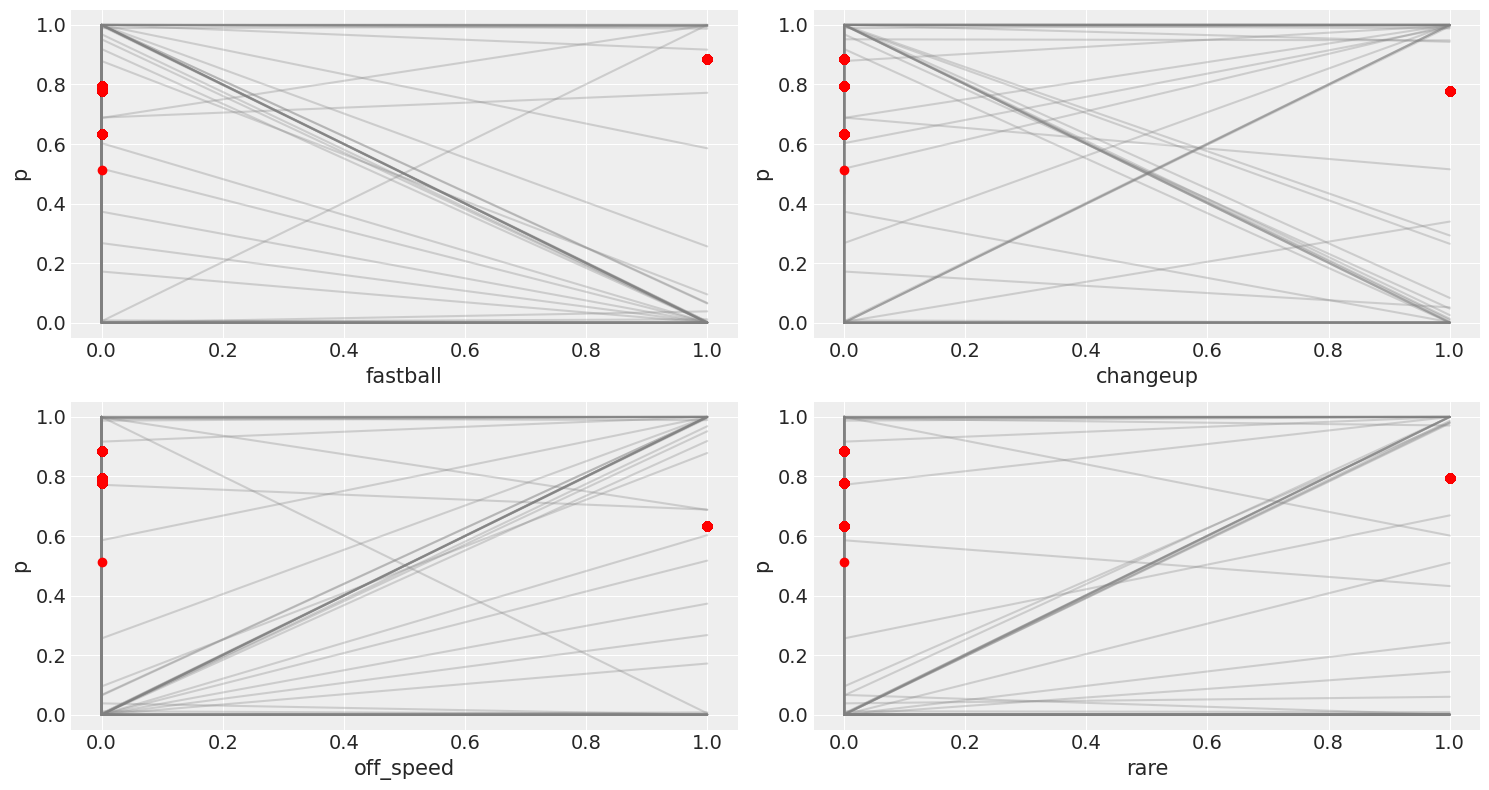

In [16]:
# Prior checking
# Create synthetic dataset
t_fb = 2
t_os = .5
t_cu = 1.2
t_rare = 1.3
t_intercept = .05

t_mu = t_intercept + (t_fb*df['fastball']) + (t_os*df['off_speed']) + (t_cu*df['changeup']) + (t_rare*df['rare'])
true_p = 1 / (1+np.exp(-t_mu))
true_outcomes = np.array((true_p > 0.5).astype(int))


with pm.Model() as pitch_type_prior:

    # Priors
    intercept = pm.Normal("intercept", mu=0, sigma=10)
    fastball = pm.HalfNormal("fastball", sigma=10)
    changeup = pm.Normal("changeup", mu=0, sigma=10)
    off_speed = pm.Normal("off_speed", mu=0, sigma=10)
    rare = pm.Normal("rare", mu=0, sigma=10)

    # Logistic transform
    mu = intercept + (fastball*df['fastball']) + (off_speed*df['off_speed']) + (changeup*df['changeup']) + (rare*df['rare'])
    p = pm.Deterministic('p', pm.math.sigmoid(mu))

    # outcome
    outcome = pm.Bernoulli("outcome", p=p, observed=true_outcomes)

    idata = pm.sample_prior_predictive(draws=50, random_seed=42)




# Get the prior predictive probabilities (loop through each prior)
col = 0
row = 0
params = ['fastball', 'changeup', 'off_speed', 'rare']  # ****CHANGE PARAMS
fig, axs = plt.subplots(ncols=2, nrows=(len(params)//2) + (len(params)%2), figsize=(15, 8))
p_prior = idata.prior["p"].values  # shape: (draws, obs)

for param in params:

  X_sorted_idx = np.argsort(df[param])
  X_sorted = df[param].values[X_sorted_idx]
  true_sorted = true_p.iloc[X_sorted_idx]

  for sig in p_prior[0]:
      # Sort data
      sig_sort = sig[X_sorted_idx]
      # Plot data
      axs[row, col].plot(X_sorted, sig_sort, color='gray', alpha=0.3)


  # plt.plot(X_sorted, p_prior_sorted[0][0], color='dodgerblue')

  axs[row, col].scatter(X_sorted, true_sorted, color='red', label='True Outcomes', zorder=3)

  axs[row, col].set_xlabel(param)
  axs[row, col].set_ylabel("p")
  # axs[row, col].legend()

  col += 1
  if col > 1:
    col = 0
    row += 1

plt.tight_layout()
plt.show()

# Create pitch_type model

Output()

array([<Axes: title={'center': 'fastball'}>,
       <Axes: title={'center': 'changeup'}>,
       <Axes: title={'center': 'off_speed'}>,
       <Axes: title={'center': 'rare'}>], dtype=object)

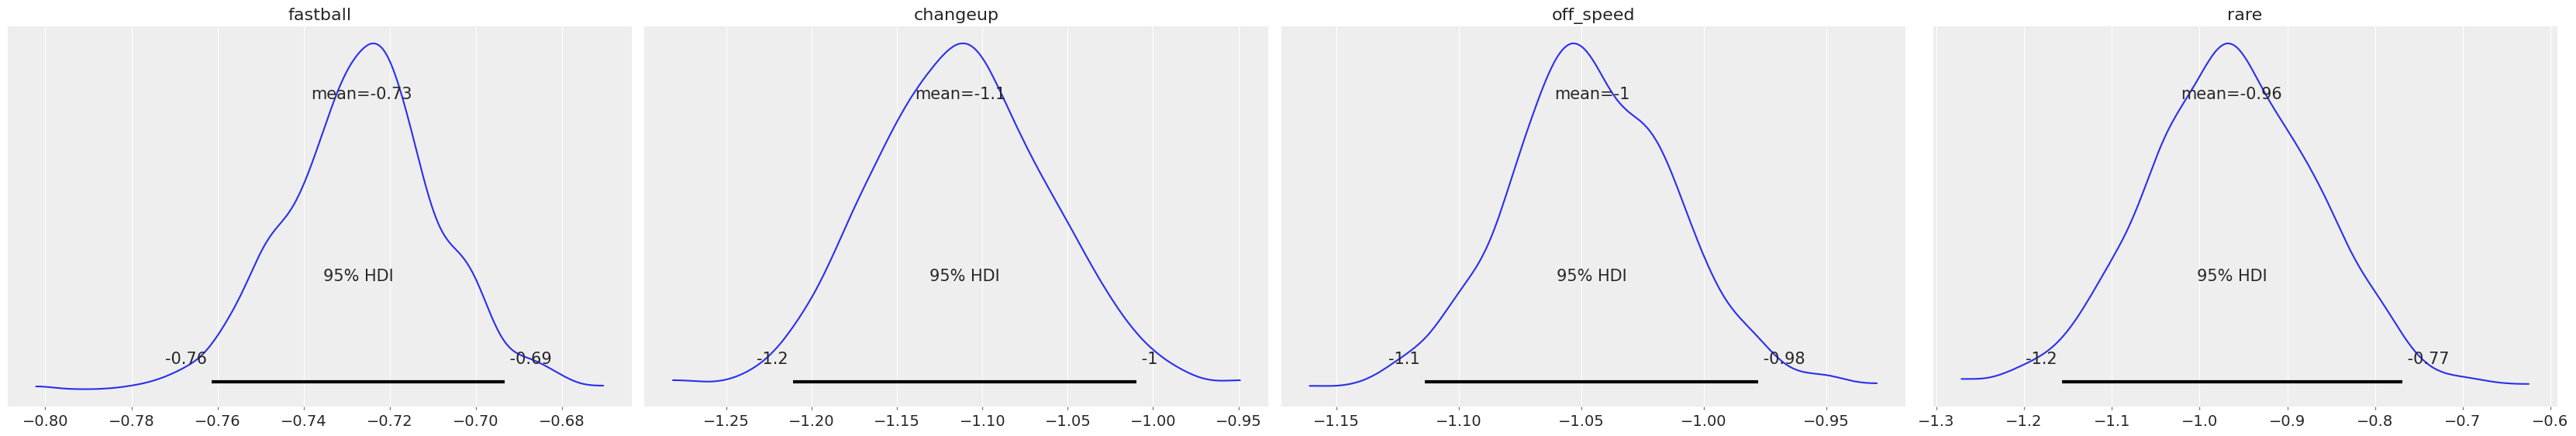

In [17]:
with pm.Model() as pitch_type:
    # Priors
    intercept = pm.Normal("intercept", mu=0, sigma=10)
    fastball = pm.Normal("fastball", mu=0, sigma=10)
    changeup = pm.Normal("changeup", mu=0, sigma=10)
    off_speed = pm.Normal("off_speed", mu=0, sigma=10)
    rare = pm.Normal("rare", mu=0, sigma=10)

    # Likelihood
    mu = intercept + (fastball*df['fastball']) + (off_speed*df['off_speed']) + (changeup*df['changeup']) + (rare*df['rare'])
    theta = pm.Deterministic('theta', pm.math.sigmoid(mu))
    y1 = pm.Bernoulli('y1', p=theta, observed=labels)

    # ELPD_LOO
    mean_field2 = pm.fit(method='advi', obj_optimizer=pm.adagrad_window(learning_rate=1e-2))
    # idata2 = pm.sample(draws=1000, idata_kwargs={"log_likelihood":True})
    # idata2.extend(pm.sample_posterior_predictive(idata2))
    # loocv_ump1["m2"] = idata2

trace_pitch_type = mean_field2.sample(1000)

# add to model comparision dict
loocv_ump1["pitch_type"] = trace_pitch_type

az.plot_posterior(trace_pitch_type, var_names=["fastball", "changeup", 'off_speed', 'rare'], hdi_prob=0.95)

**Accuracy**

In [19]:
# Init param samples
param_samples = {}

# Make predictions for each posterior sample
n_samples = len(trace_pitch_type.posterior['intercept']) # ****CHANGE TRACE (when copied and aplied to other model)
n_obs = len(df_test)

# Initialize predictions array
all_preds = np.zeros((n_samples, n_obs))

# Get samples from each param (generalized for any number of params)
for param in ['intercept', 'fastball', 'changeup', 'off_speed', 'rare']:
    param_samples[param] = trace_pitch_type.posterior[param].values.flatten()


# Make predictions
for i in range(n_samples):
  # Use df_test!
  mu = param_samples['intercept'][i] + (
      (param_samples['fastball'][i]*df_test['fastball']) + (param_samples['off_speed'][i]*df_test['off_speed']) + (param_samples['changeup'][i]*df_test['changeup']) + (param_samples['rare'][i]*df_test['rare'])
  )
  all_preds[i, :] = 1 / (1 + np.exp(-mu))  # sigmoid function

# Make predictions
y_pred_proba = all_preds.mean(axis=0)
y_pred = (y_pred_proba > 0.5).astype(int)

# Calculate accuracy
accuracy = np.mean(y_pred == df_test['error_in_decision'])
model_accuracies["pitch_type"] = accuracy

# print accuracy
print(f"Accuracy: {accuracy}")
print(f"Number of Category 0: {np.sum(y_pred == 0)}")
print(f"Number of Category 1: {np.sum(y_pred == 1)}")

Accuracy: 0.8702772963604852
Number of Category 0: 11540
Number of Category 1: 0


# 2) Count
- Balls, strikes, pitch_number, at_bat_number, description

**Prior Checking**

<ipython-input-20-b5cc6c12c330>:67: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


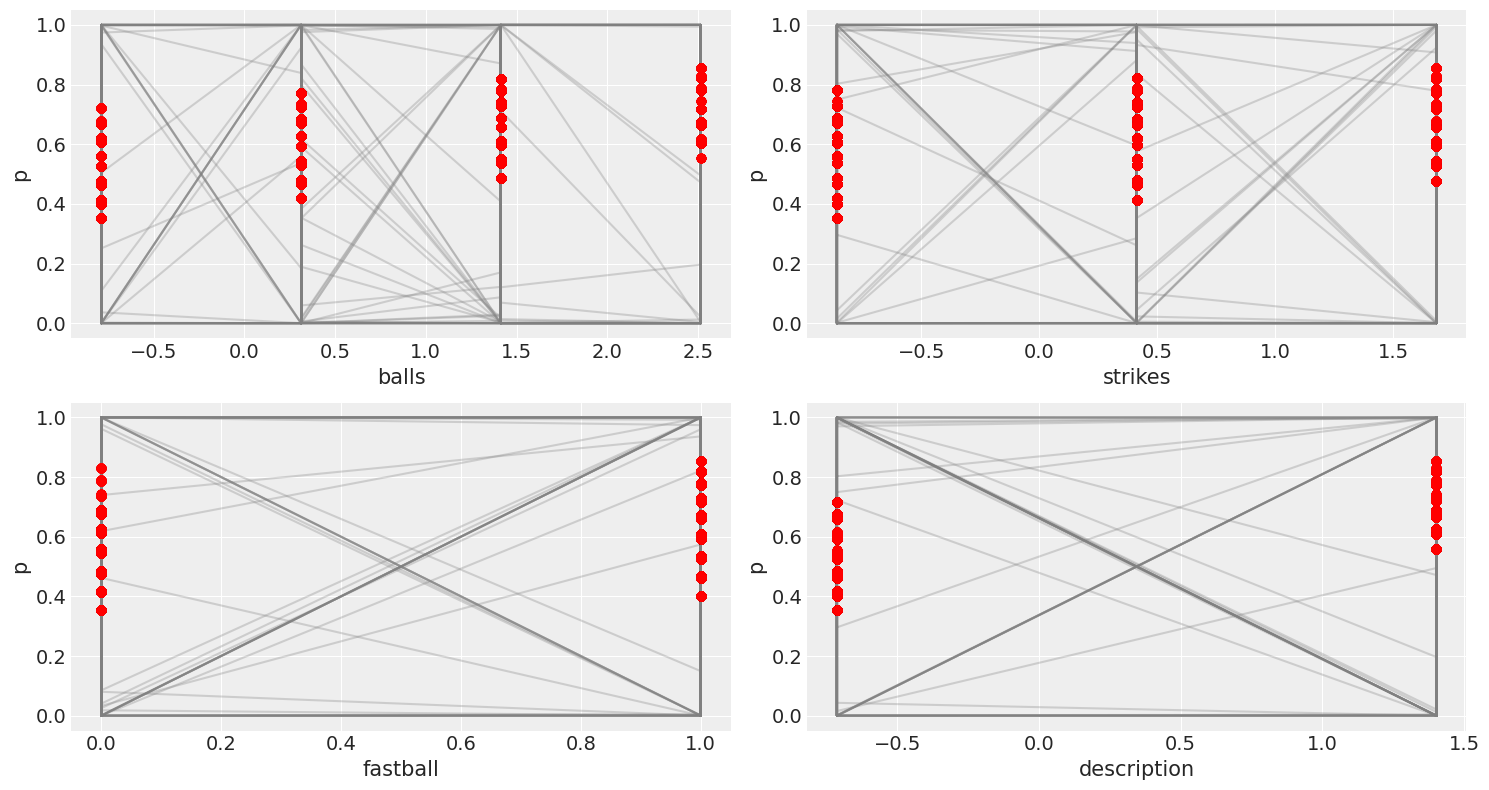

In [20]:
# Prior checking
# Create synthetic dataset
t_balls = .25
t_strikes = .2
t_fastball = .2
t_description = 0.4

t_mu = t_intercept + (t_balls*df['balls']) + (t_strikes*df['strikes']) + (t_fastball*df['fastball']) + (t_description*df['description'])
true_p = 1 / (1+np.exp(-t_mu))
true_outcomes = np.array((true_p > 0.5).astype(int))


with pm.Model() as pitch_type_prior:

    # Priors
    intercept = pm.Normal("intercept", mu=0, sigma=10)  # ****CHANGE ALL PRIORS
    balls = pm.Normal("balls", mu=0, sigma=10)
    strikes = pm.Normal("strikes", mu=0, sigma=10)
    fastball = pm.Normal("fastball", mu=0, sigma=10)
    description = pm.Normal("description", mu=0, sigma=10)

    # Logistic transform
    mu = intercept + (balls*df['balls']) + (strikes*df['strikes']) + (fastball*df['fastball']) + (description*df['description']) # ****CHANGE EQUATION
    p = pm.Deterministic('p', pm.math.sigmoid(mu))

    # outcome
    outcome = pm.Bernoulli("outcome", p=p, observed=true_outcomes)

    idata = pm.sample_prior_predictive(draws=50, random_seed=42)




# Get the prior predictive probabilities (loop through each prior)
col = 0
row = 0
params = ["balls", 'strikes', 'fastball', 'description']  # ****CHANGE PARAMS
fig, axs = plt.subplots(ncols=2, nrows=(len(params)//2) + (len(params)%2), figsize=(15, 8))
p_prior = idata.prior["p"].values  # shape: (draws, obs)

for param in params:

  X_sorted_idx = np.argsort(df[param])
  X_sorted = df[param].values[X_sorted_idx]
  true_sorted = true_p.iloc[X_sorted_idx]

  for sig in p_prior[0]:
      # Sort data
      sig_sort = sig[X_sorted_idx]
      # Plot data
      axs[row, col].plot(X_sorted, sig_sort, color='gray', alpha=0.3)


  # plt.plot(X_sorted, p_prior_sorted[0][0], color='dodgerblue')

  axs[row, col].scatter(X_sorted, true_sorted, color='red', label='True Outcomes', zorder=3)

  axs[row, col].set_xlabel(param)
  axs[row, col].set_ylabel("p")
  # axs[row, col].legend()

  col += 1
  if col > 1:
    col = 0
    row += 1

plt.tight_layout()
plt.show()

**Create Model**

Output()

array([<Axes: title={'center': 'balls'}>,
       <Axes: title={'center': 'strikes'}>,
       <Axes: title={'center': 'fastball'}>,
       <Axes: title={'center': 'description'}>], dtype=object)

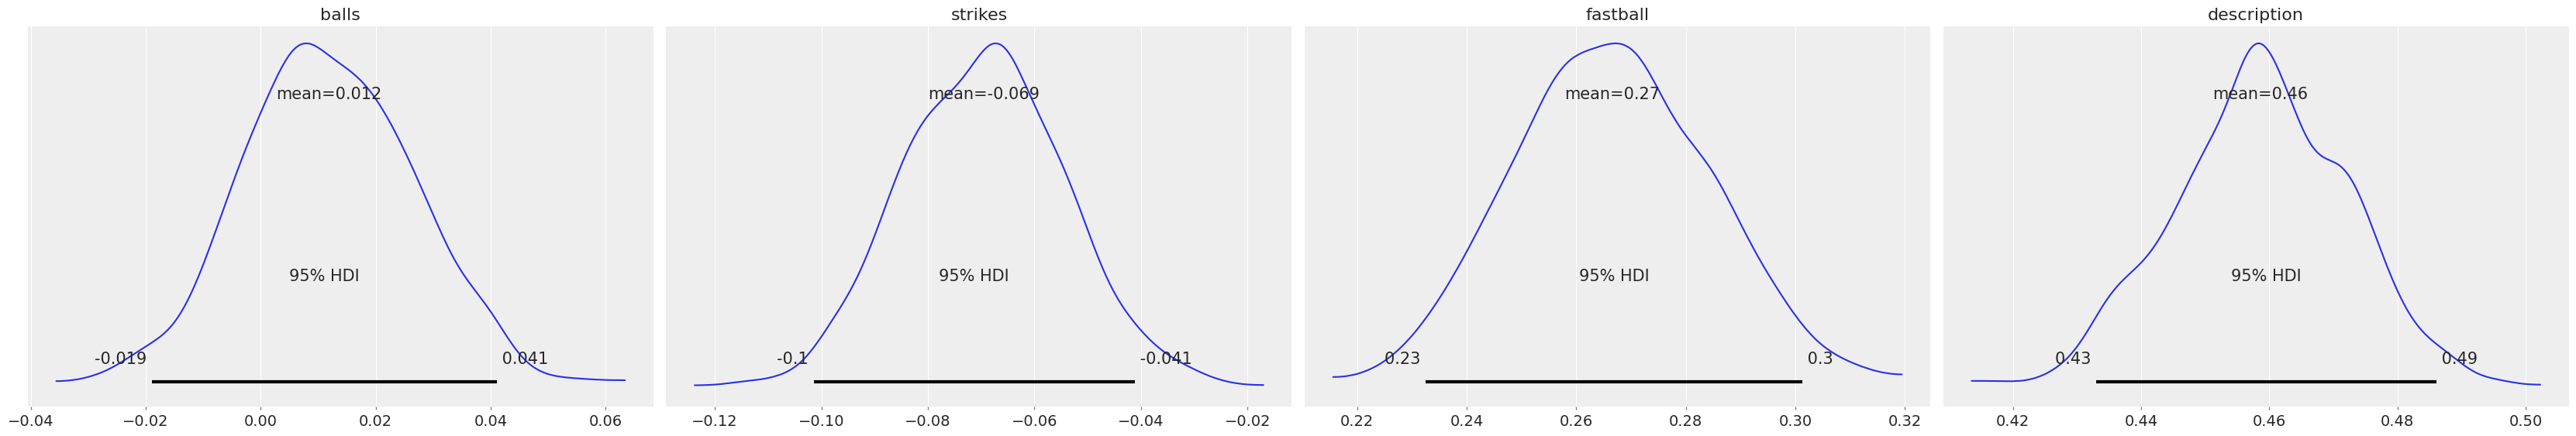

In [21]:
# Create first model looking at count
# balls, strikes, pitch type, description (called ball: 0, or strike: 1)
with pm.Model() as count:
    # Priors
    intercept = pm.Normal("intercept", mu=0, sigma=10)
    balls = pm.Normal("balls", mu=0, sigma=10)
    strikes = pm.Normal("strikes", mu=0, sigma=10)
    fastball = pm.Normal("fastball", mu=0, sigma=10)
    description = pm.Normal("description", mu=0, sigma=10)

    # Likelihood
    mu = intercept + (balls*df['balls']) + (strikes*df['strikes']) + (fastball*df['fastball']) + (description*df['description'])
    theta = pm.Deterministic('theta', pm.math.sigmoid(mu))
    y1 = pm.Bernoulli('y1', p=theta, observed=labels)

    # ELPD_LOO
    mean_field5 = pm.fit(method='advi', obj_optimizer=pm.adagrad_window(learning_rate=1e-2))
    # idata2 = pm.sample(draws=1000, idata_kwargs={"log_likelihood":True})
    # idata2.extend(pm.sample_posterior_predictive(idata2))
    # loocv_ump1["m2"] = idata2

    trace_count = mean_field5.sample(1000)

# add to model comparision dict
loocv_ump1["count"] = trace_count

az.plot_posterior(trace_count, var_names=["balls", 'strikes', 'fastball', 'description'], hdi_prob=0.95)

**Accuracy**

In [22]:
# Init param samples
param_samples = {}

# Make predictions for each posterior sample
n_samples = len(trace_count.posterior['intercept']) # ****CHANGE TRACE (when copied and aplied to other model)
n_obs = len(df_test)

# Initialize predictions array
all_preds = np.zeros((n_samples, n_obs))

# Add intercept
param_samples['intercept'] = trace_count.posterior['intercept'].values.flatten() # ****CHANGE TRACE (when copied and aplied to other model)

# Get samples from each param (generalized for any number of params)
for param in ["balls", 'strikes', 'fastball', 'description']: # ****CHANGE PARAMS LIST (when copied and aplied to other model)
    param_samples[param] = trace_count.posterior[param].values.flatten()

# Make predictions
for i in range(n_samples):
  # Use df_test!
  # ****CHANGE MU PARAMS BEING USED (when copied and aplied to other model)
  mu = param_samples['intercept'][i] + (
      (param_samples['balls'][i]*df_test['balls']) + (param_samples['strikes'][i]*df_test['strikes']) + (param_samples['fastball'][i]*df_test['fastball']) + (param_samples['description'][i]*df_test['description'])
  )
  all_preds[i, :] = 1 / (1 + np.exp(-mu))  # sigmoid function

# Make predictions
y_pred_proba = all_preds.mean(axis=0)
y_pred = (y_pred_proba > 0.5).astype(int)

# Calculate accuracy
accuracy = np.mean(y_pred == df_test['error_in_decision'])
model_accuracies["count"] = accuracy    # ****CHANGE NAME OF MODEL KEY (when copied and aplied to other model)

# print accuracy
print(f"Accuracy: {accuracy}")
print(f"Number of Category 0: {np.sum(y_pred == 0)}")
print(f"Number of Category 1: {np.sum(y_pred == 1)}")

Accuracy: 0.8702772963604852
Number of Category 0: 11540
Number of Category 1: 0


# 3) Pitch characteristics
- plate_z, plate_x, release_speed, release_pos_x, release_pos_z, release_pos_y, pitch_location

**Prior Checking**

<ipython-input-23-8078c5d85498>:79: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


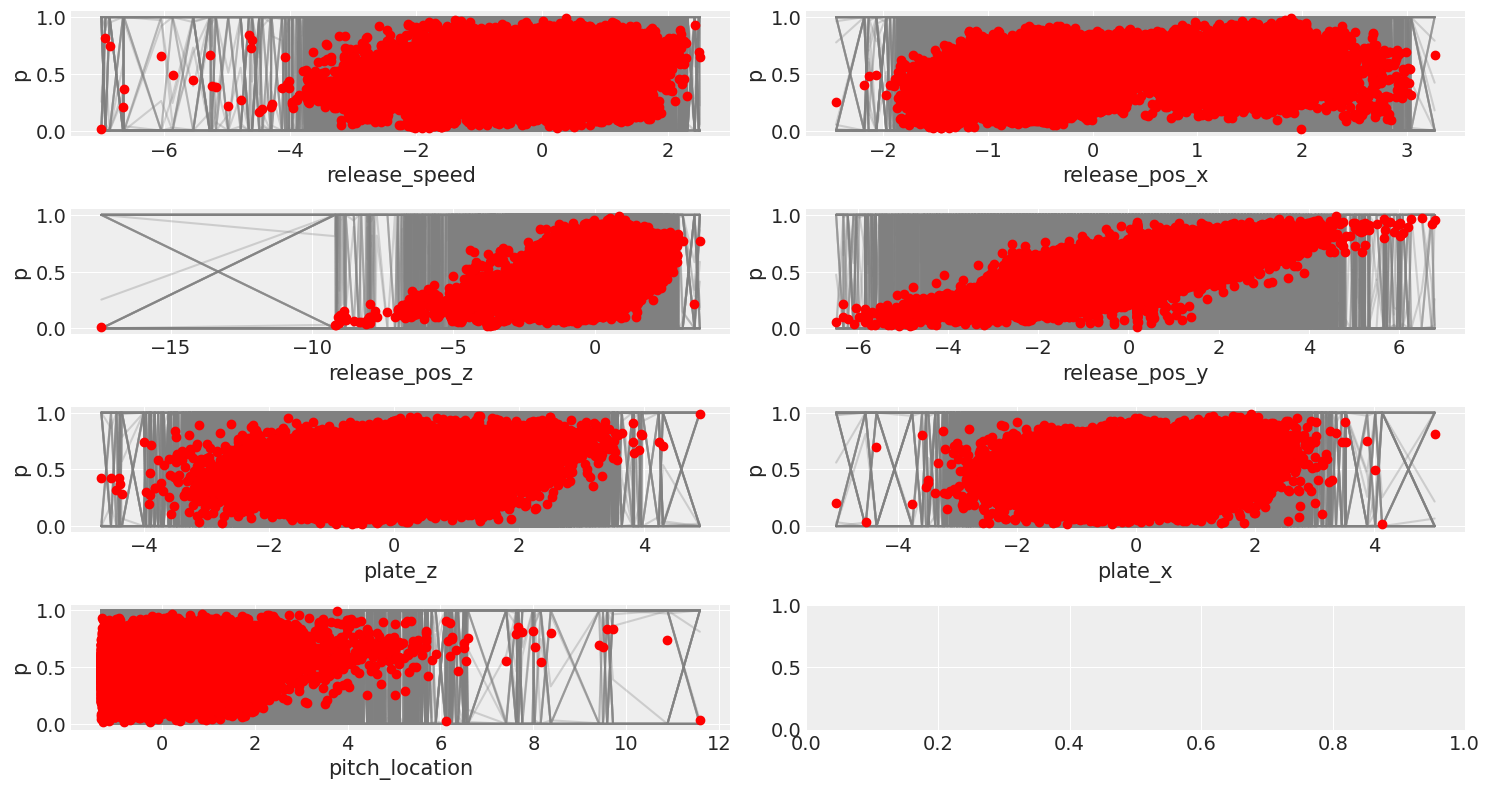

In [23]:
# Prior checking
# Create synthetic dataset
t_release_speed = .25
t_release_pos_x = .2
t_release_pos_z = .2
t_release_pos_y = 0.4
t_pitch_location = .2
t_plate_z = .2
t_plate_x = .2

t_mu = t_intercept + (
        (t_release_speed*df['release_speed']) + (t_release_pos_x*df['release_pos_x']) + (t_release_pos_z*df['release_pos_z']) + (t_release_pos_y*df['release_pos_y'])
        + (t_pitch_location*df['pitch_location']) + (t_plate_z*df['plate_z']) + (t_plate_x*df['plate_x'])
    )
true_p = 1 / (1+np.exp(-t_mu))
true_outcomes = np.array((true_p > 0.5).astype(int))


with pm.Model() as prior_check:

    # Priors
    intercept = pm.Normal("intercept", mu=0, sigma=10)  # ****CHANGE ALL PRIORS
    release_speed = pm.Normal("release_speed", mu=0, sigma=10)
    release_pos_x = pm.Normal("release_pos_x", mu=0, sigma=10)
    release_pos_z = pm.Normal("release_pos_z", mu=0, sigma=10)
    release_pos_y = pm.Normal("release_pos_y", mu=0, sigma=10)
    pitch_location = pm.Normal("pitch_location", mu=0, sigma=10)
    plate_z = pm.Normal("plate_z", mu=0, sigma=10)
    plate_x = pm.Normal("plate_x", mu=0, sigma=10)

    # Logistic transform
    mu = intercept + (
        (release_speed*df['release_speed']) + (release_pos_x*df['release_pos_x']) + (release_pos_z*df['release_pos_z']) + (release_pos_y*df['release_pos_y'])
        + (pitch_location*df['pitch_location']) + (plate_z*df['plate_z']) + (plate_x*df['plate_x'])
    )
    p = pm.Deterministic('p', pm.math.sigmoid(mu))

    # outcome
    outcome = pm.Bernoulli("outcome", p=p, observed=true_outcomes)

    idata = pm.sample_prior_predictive(draws=50, random_seed=42)




# Get the prior predictive probabilities (loop through each prior)
col = 0
row = 0
params = ["release_speed", 'release_pos_x', 'release_pos_z', 'release_pos_y', 'plate_z', 'plate_x', 'pitch_location']  # ****CHANGE PARAMS
fig, axs = plt.subplots(ncols=2, nrows=(len(params)//2) + (len(params)%2), figsize=(15, 8))
p_prior = idata.prior["p"].values  # shape: (draws, obs)

for param in params:

  X_sorted_idx = np.argsort(df[param])
  X_sorted = df[param].values[X_sorted_idx]
  true_sorted = true_p.iloc[X_sorted_idx]

  for sig in p_prior[0]:
      # Sort data
      sig_sort = sig[X_sorted_idx]
      # Plot data
      axs[row, col].plot(X_sorted, sig_sort, color='gray', alpha=0.3)


  # plt.plot(X_sorted, p_prior_sorted[0][0], color='dodgerblue')

  axs[row, col].scatter(X_sorted, true_sorted, color='red', label='True Outcomes', zorder=3)

  axs[row, col].set_xlabel(param)
  axs[row, col].set_ylabel("p")
  # axs[row, col].legend()

  col += 1
  if col > 1:
    col = 0
    row += 1

plt.tight_layout()
plt.show()

**Create Model**

Output()

array([[<Axes: title={'center': 'release_speed'}>,
        <Axes: title={'center': 'release_pos_x'}>,
        <Axes: title={'center': 'release_pos_z'}>],
       [<Axes: title={'center': 'release_pos_y'}>,
        <Axes: title={'center': 'plate_z'}>,
        <Axes: title={'center': 'plate_x'}>],
       [<Axes: title={'center': 'pitch_location'}>, <Axes: >, <Axes: >]],
      dtype=object)

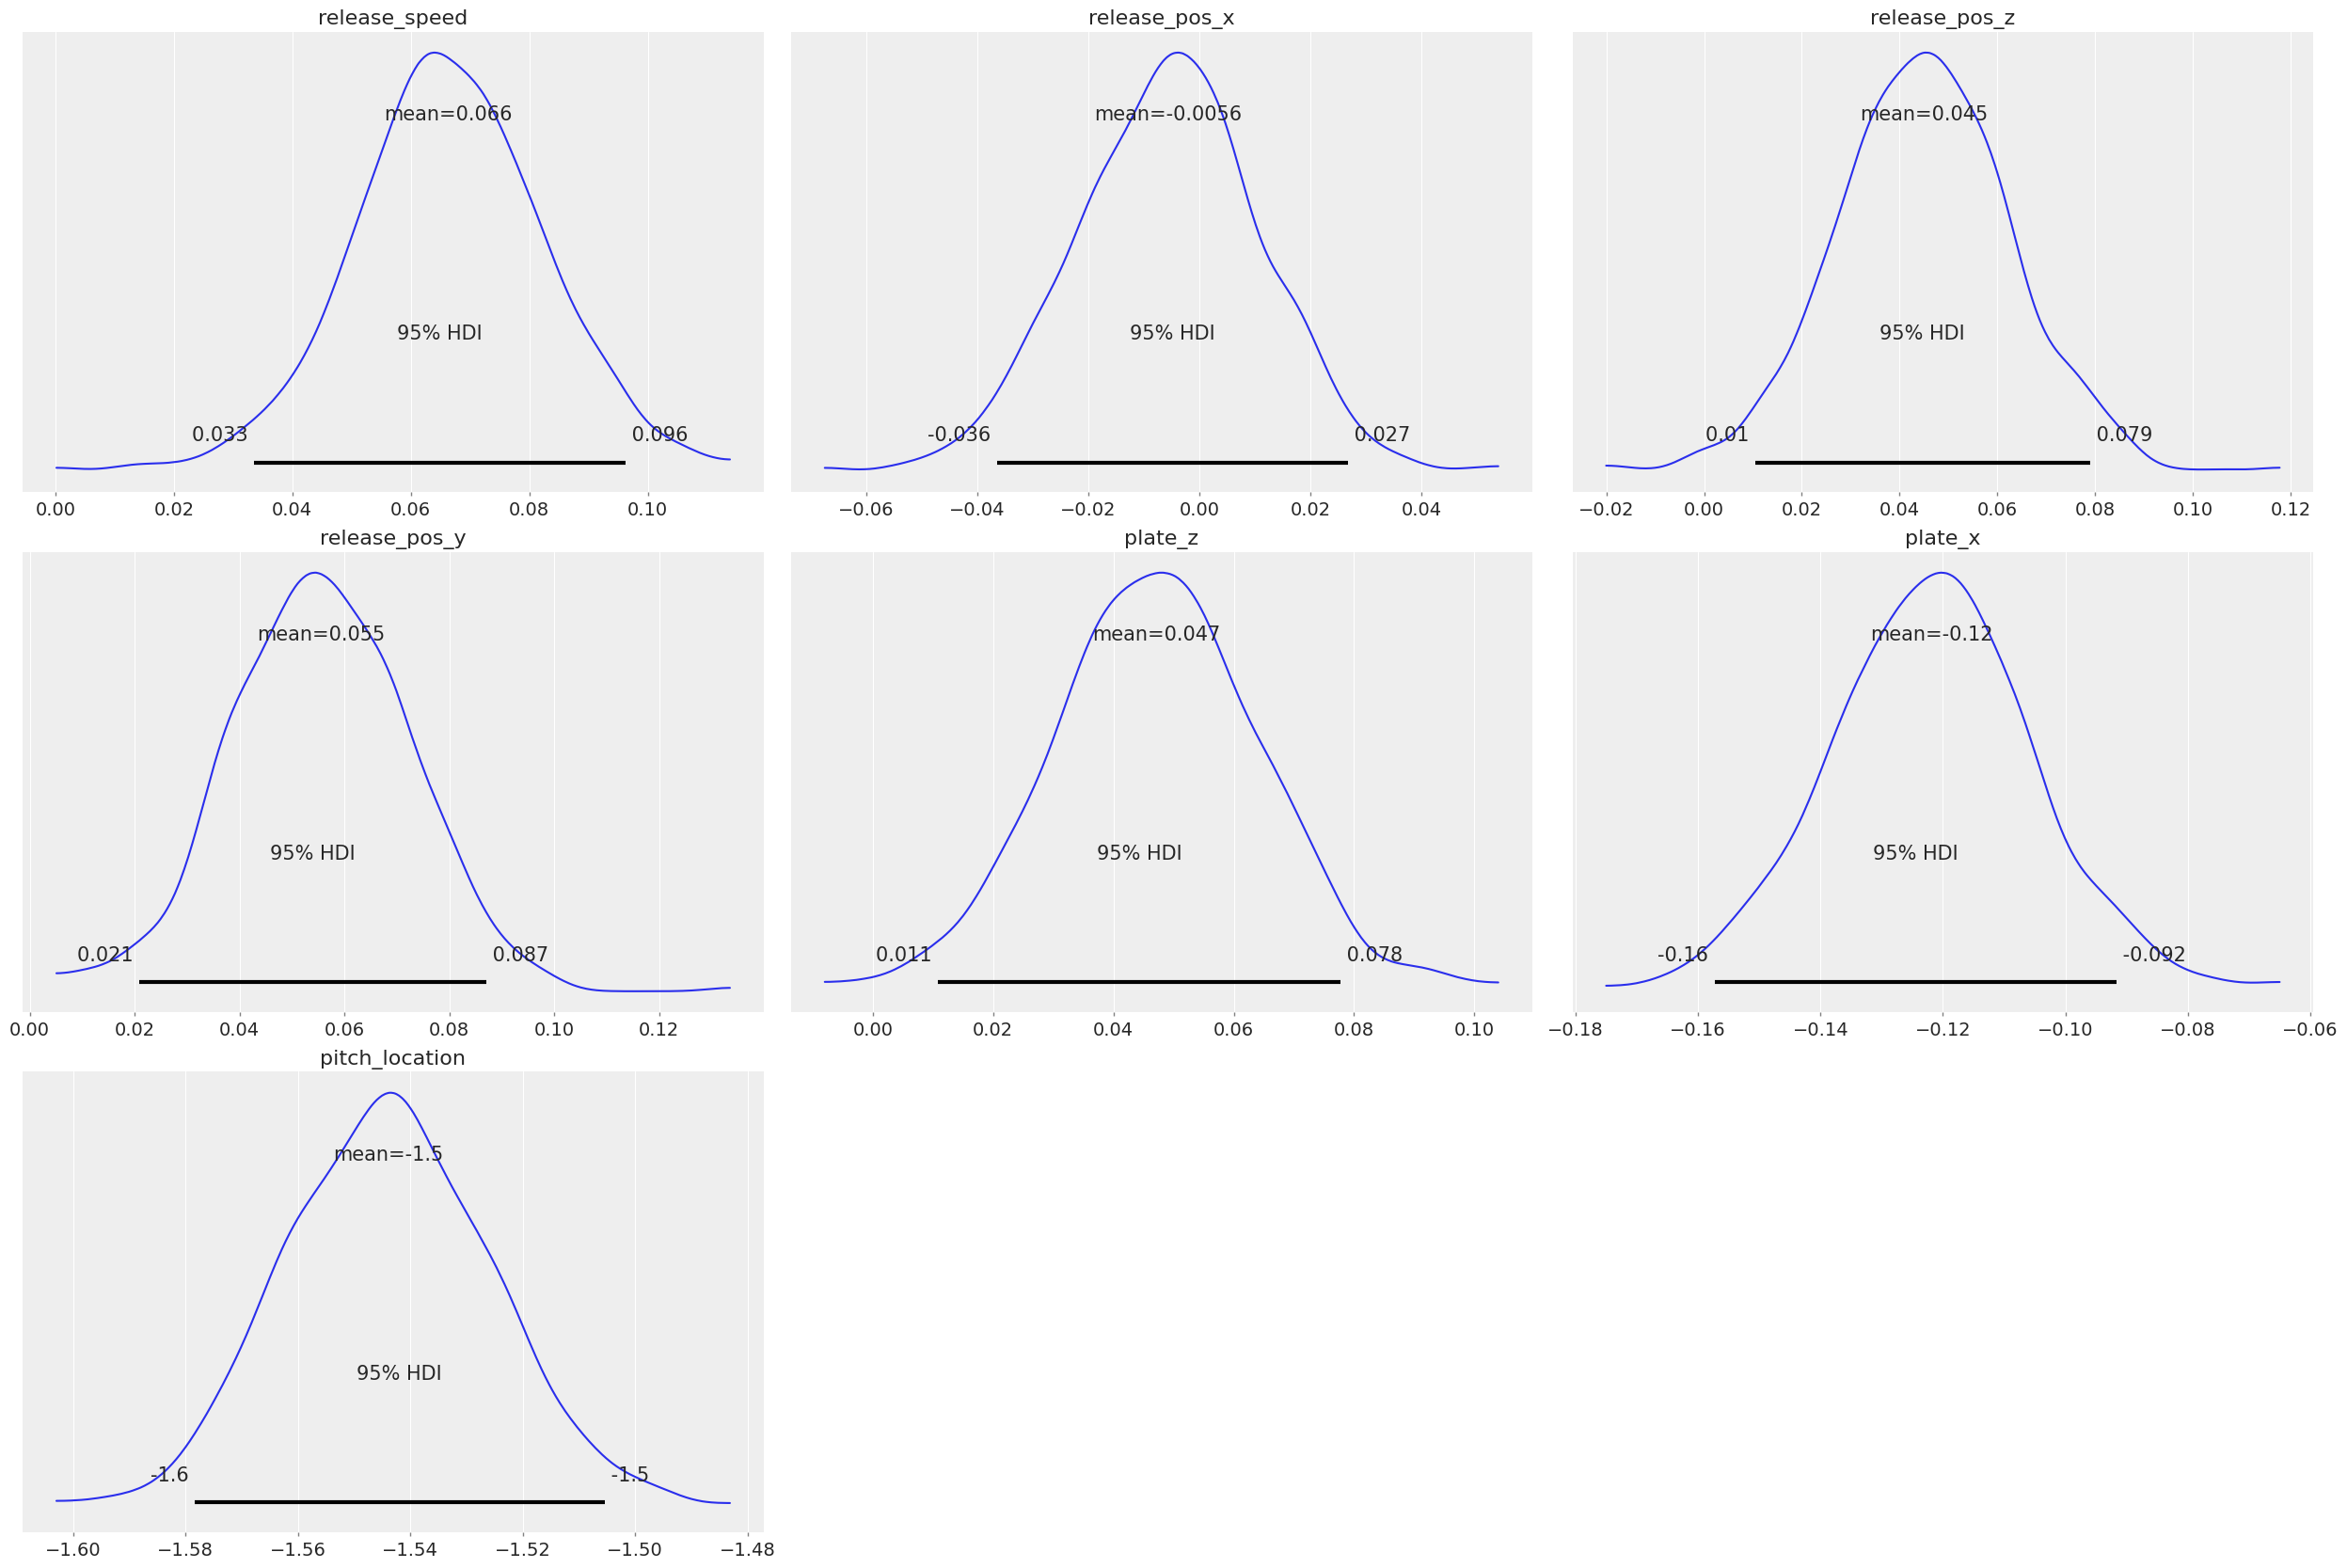

In [24]:
with pm.Model() as pitch_characteristics:
    # Priors
    intercept = pm.Normal("intercept", mu=0, sigma=10)
    release_speed = pm.Normal("release_speed", mu=0, sigma=10)
    release_pos_x = pm.Normal("release_pos_x", mu=0, sigma=10)
    release_pos_z = pm.Normal("release_pos_z", mu=0, sigma=10)
    release_pos_y = pm.Normal("release_pos_y", mu=0, sigma=10)
    pitch_location = pm.Normal("pitch_location", mu=0, sigma=10)
    plate_z = pm.Normal("plate_z", mu=0, sigma=10)
    plate_x = pm.Normal("plate_x", mu=0, sigma=10)


    # Likelihood
    mu = intercept + (
        (release_speed*df['release_speed']) + (release_pos_x*df['release_pos_x']) + (release_pos_z*df['release_pos_z']) + (release_pos_y*df['release_pos_y'])
        + (pitch_location*df['pitch_location']) + (plate_z*df['plate_z']) + (plate_x*df['plate_x'])
    )
    theta = pm.Deterministic('theta', pm.math.sigmoid(mu))
    y1 = pm.Bernoulli('y1', p=theta, observed=labels)

    # ELPD_LOO
    mean_field3 = pm.fit(method='advi', obj_optimizer=pm.adagrad_window(learning_rate=1e-2))
    # idata2 = pm.sample(draws=1000, idata_kwargs={"log_likelihood":True})
    # idata2.extend(pm.sample_posterior_predictive(idata2))
    # loocv_ump1["m2"] = idata2

trace_pitch_characteristics = mean_field3.sample(1000)

# add to model comparision dict
loocv_ump1["pitch_characteristics"] = trace_pitch_characteristics

# - plate_z, plate_x, release_speed, release_pos_x, release_pos_z, release_pos_y, pitch_location
az.plot_posterior(trace_pitch_characteristics, var_names=["release_speed", 'release_pos_x', 'release_pos_z', 'release_pos_y', 'plate_z', 'plate_x', 'pitch_location'], hdi_prob=0.95)

**Accuracy**

In [25]:
# Init param samples
param_samples = {}

# Make predictions for each posterior sample
n_samples = len(trace_pitch_characteristics.posterior['intercept']) # ****CHANGE TRACE (when copied and aplied to other model)
n_obs = len(df_test)

# Initialize predictions array
all_preds = np.zeros((n_samples, n_obs))

# Add intercept
param_samples['intercept'] = trace_pitch_characteristics.posterior['intercept'].values.flatten() # ****CHANGE TRACE (when copied and aplied to other model)

# Get samples from each param (generalized for any number of params)
for param in ["release_speed", 'release_pos_x', 'release_pos_z', 'release_pos_y', 'plate_z', 'plate_x', 'pitch_location']: # ****CHANGE PARAMS LIST (when copied and aplied to other model)
    param_samples[param] = trace_pitch_characteristics.posterior[param].values.flatten()  # ****CHANGE TRACE (when copied and aplied to other model)

# Make predictions
for i in range(n_samples):
  # Use df_test!
  # ****CHANGE MU PARAMS BEING USED (when copied and aplied to other model)
  mu = param_samples['intercept'][i] + (
      (param_samples['release_speed'][i]*df_test['release_speed']) + (param_samples['release_pos_x'][i]*df_test['release_pos_x'])
       + (param_samples['release_pos_z'][i]*df_test['release_pos_z']) + (param_samples['release_pos_y'][i]*df_test['release_pos_y']) + (param_samples['plate_z'][i]*df_test['plate_z'])
       + (param_samples['plate_x'][i]*df_test['plate_x']) + (param_samples['pitch_location'][i]*df_test['pitch_location'])
  )
  all_preds[i, :] = 1 / (1 + np.exp(mu))  # sigmoid function

# Make predictions
y_pred_proba = all_preds.mean(axis=0)
y_pred = (y_pred_proba > 0.5).astype(int)

# Calculate accuracy
accuracy = np.mean(y_pred == df_test['error_in_decision'])
model_accuracies["pitch_characteristics"] = accuracy    # ****CHANGE NAME OF MODEL KEY (when copied and aplied to other model)

# print accuracy
print(f"Accuracy: {accuracy}")
print(f"Number of Category 0: {np.sum(y_pred == 0)}")
print(f"Number of Category 1: {np.sum(y_pred == 1)}")

Accuracy: 0.8702772963604852
Number of Category 0: 11540
Number of Category 1: 0


# 4) Movement and velocity profile:
- pfx_x, pfx_z, vx0, vy0, vz0, ax, ay, az

**Prior Checks**

<ipython-input-26-f38cb343ba5d>:78: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


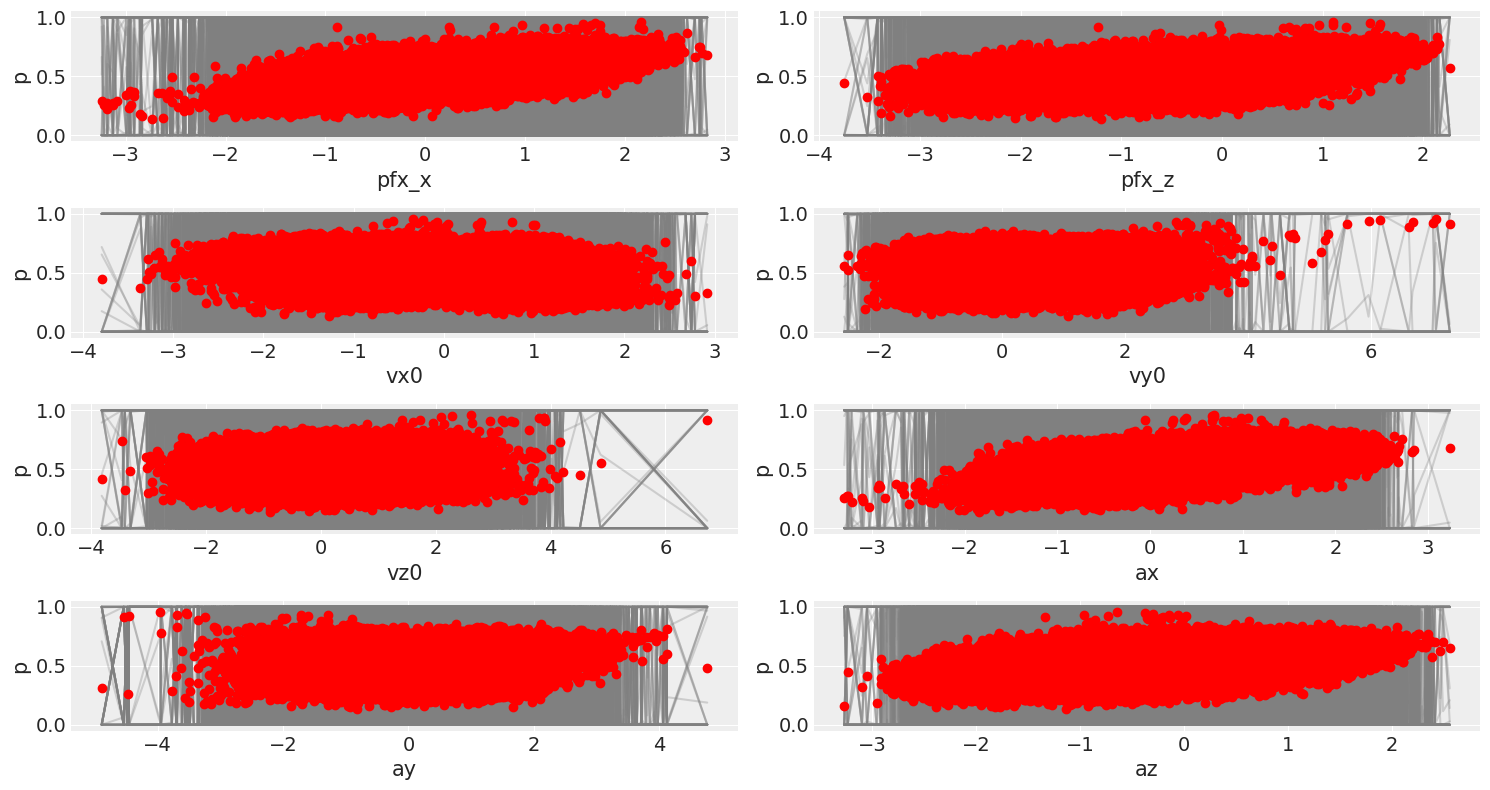

In [26]:
# Prior checking
# Create synthetic dataset
# ****CHNAGE THESE
t_pfx_x = .25
t_pfx_z = .2
t_vx0 = .2
t_vy0 = 0.4
t_vz0 = .2
t_accx = .2
t_accy = .2
t_accz = .4

# ****CHANGE T_MU
t_mu = t_intercept + (t_pfx_x*df['pfx_x']) + (t_pfx_z*df['pfx_z']) + (t_vx0*df['vx0']) + (t_vy0*df['vy0']) + (t_vz0*df['vz0']) + (t_accx*df['ax']) + (t_accy*df['ay']) + (t_accz*df['az'])
true_p = 1 / (1+np.exp(-t_mu))
true_outcomes = np.array((true_p > 0.5).astype(int))


with pm.Model() as prior_check:

    # Priors
    intercept = pm.Normal("intercept", mu=0, sigma=10)  # ****CHANGE ALL PRIORS
    pfx_x = pm.Normal("pfx_x", mu=0, sigma=10)
    pfx_z = pm.Normal("pfx_z", mu=0, sigma=10)
    vx0 = pm.Normal("vx0", mu=0, sigma=10)
    vy0 = pm.Normal("vy0", mu=0, sigma=10)
    vz0 = pm.Normal("vz0", mu=0, sigma=10)
    accx = pm.Normal("accx", mu=0, sigma=10)
    accy = pm.Normal("accy", mu=0, sigma=10)
    accz = pm.Normal("accz", mu=0, sigma=10)

    # Logistic transform
    # ****CHANGE MU
    mu = intercept + (pfx_x*df['pfx_x']) + (pfx_z*df['pfx_z']) + (vx0*df['vx0']) + (vy0*df['vy0']) + (vz0*df['vz0']) + (accx*df['ax']) + (accy*df['ay']) + (accz*df['az'])
    p = pm.Deterministic('p', pm.math.sigmoid(mu))

    # outcome
    outcome = pm.Bernoulli("outcome", p=p, observed=true_outcomes)

    idata = pm.sample_prior_predictive(draws=50, random_seed=42)




# Get the prior predictive probabilities (loop through each prior)
col = 0
row = 0
params = ['pfx_x', 'pfx_z', 'vx0', 'vy0', 'vz0', 'ax', 'ay', 'az']  # ****CHANGE PARAMS
fig, axs = plt.subplots(ncols=2, nrows=(len(params)//2) + (len(params)%2), figsize=(15, 8))
p_prior = idata.prior["p"].values  # shape: (draws, obs)

for param in params:

  X_sorted_idx = np.argsort(df[param])
  X_sorted = df[param].values[X_sorted_idx]
  true_sorted = true_p.iloc[X_sorted_idx]

  for sig in p_prior[0]:
      # Sort data
      sig_sort = sig[X_sorted_idx]
      # Plot data
      axs[row, col].plot(X_sorted, sig_sort, color='gray', alpha=0.3)


  # plt.plot(X_sorted, p_prior_sorted[0][0], color='dodgerblue')

  axs[row, col].scatter(X_sorted, true_sorted, color='red', label='True Outcomes', zorder=3)

  axs[row, col].set_xlabel(param)
  axs[row, col].set_ylabel("p")
  # axs[row, col].legend()

  col += 1
  if col > 1:
    col = 0
    row += 1

plt.tight_layout()
plt.show()

**Create Model**

Output()

array([[<Axes: title={'center': 'pfx_x'}>,
        <Axes: title={'center': 'pfx_z'}>,
        <Axes: title={'center': 'vx0'}>, <Axes: title={'center': 'vy0'}>],
       [<Axes: title={'center': 'vz0'}>,
        <Axes: title={'center': 'accx'}>,
        <Axes: title={'center': 'accy'}>,
        <Axes: title={'center': 'accz'}>]], dtype=object)

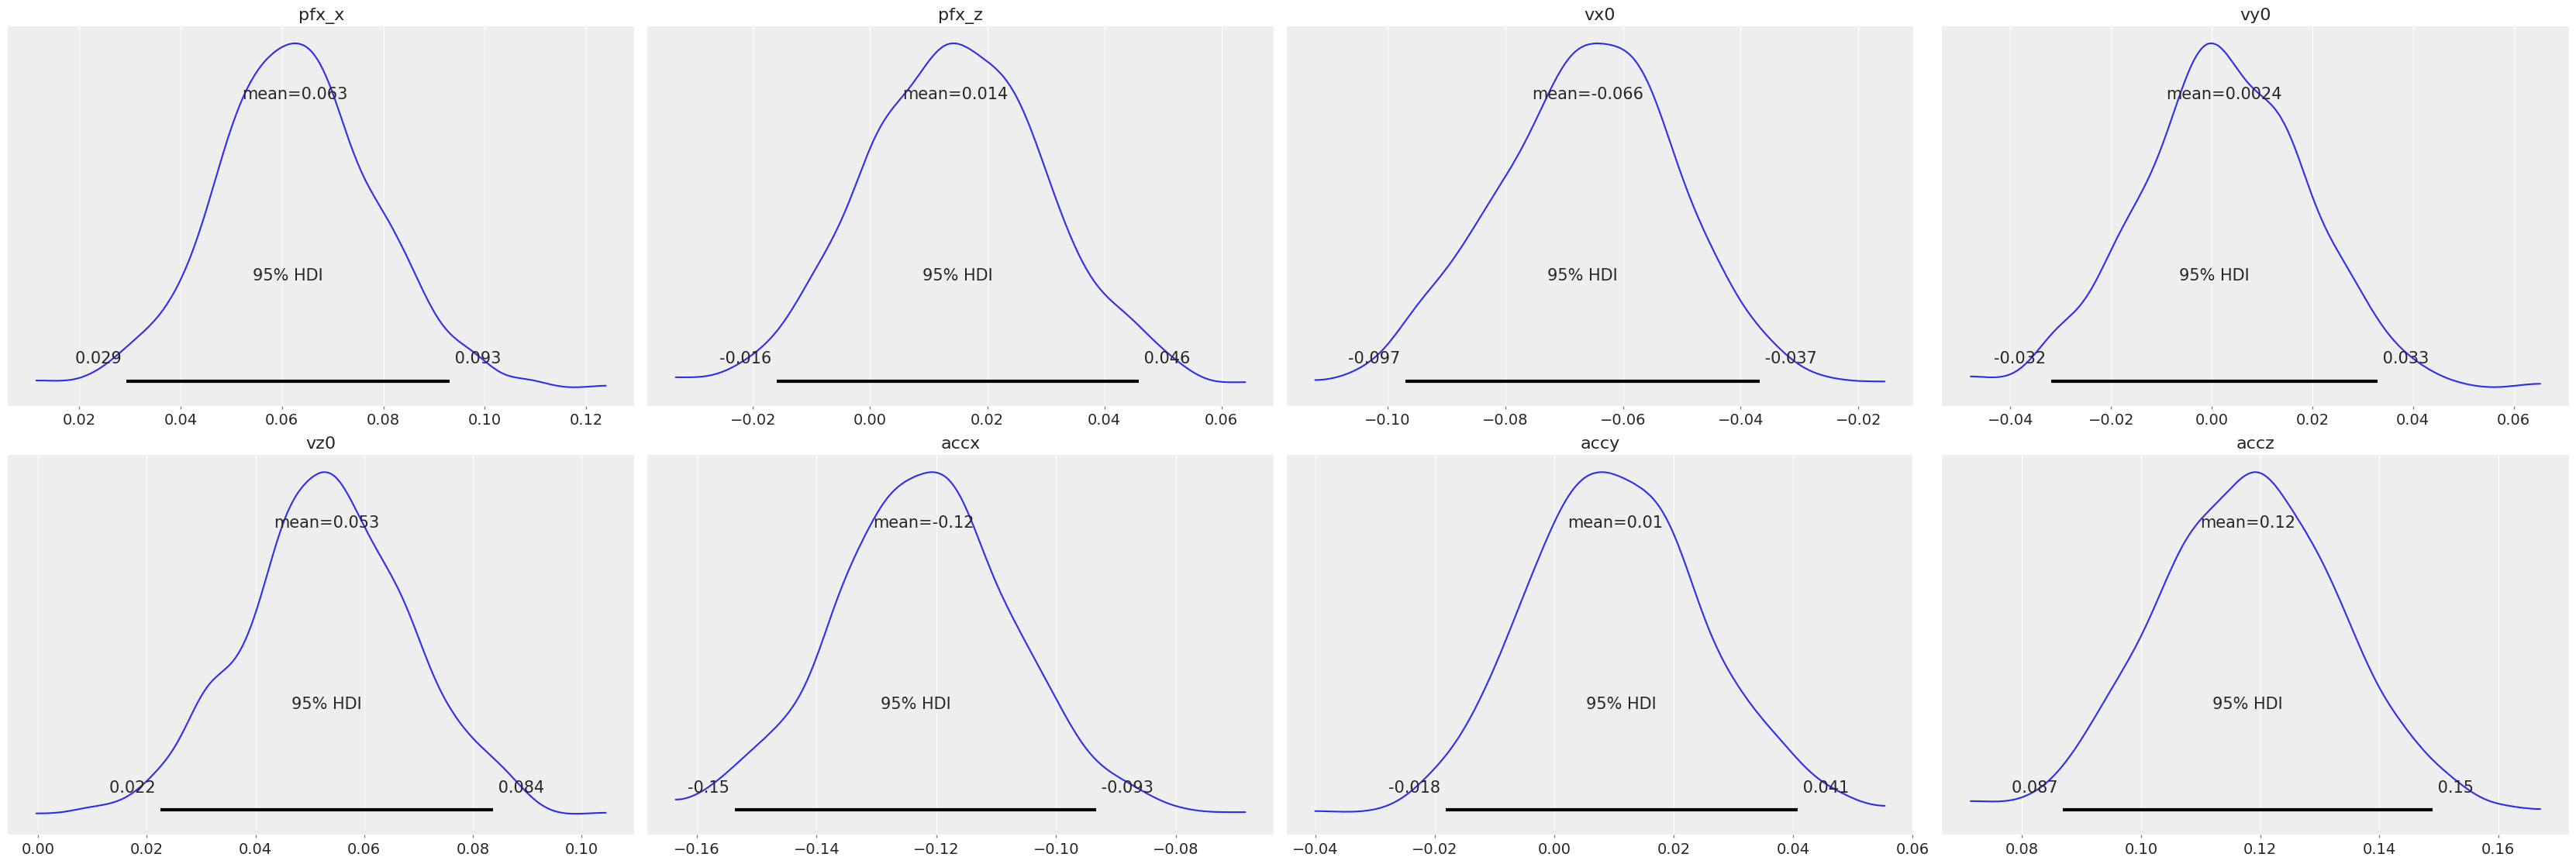

In [27]:
# pfx_x: Horizontal movement in feet from the catcher's perspective.
# pfx_z: Vertical movement in feet from the catcher's perspective.
# vx0: Velocity of the pitch in the x-dimension (feet/sec), determined at y=50 feet.
# vy0: Velocity of the pitch in the y-dimension (feet/sec), determined at y=50 feet.
# vz0: Velocity of the pitch in the z-dimension (feet/sec), determined at y=50 feet.
# ax: Acceleration of the pitch in the x-dimension (feet/sec²), determined at y=50 feet.
# ay: Acceleration of the pitch in the y-dimension (feet/sec²), determined at y=50 feet.
# az: Acceleration of the pitch in the z-dimension (feet/sec²), determined at y=50 feet.

# movement
with pm.Model() as profile:
    # Priors
    intercept = pm.Normal("intercept", mu=0, sigma=10)
    pfx_x = pm.Normal("pfx_x", mu=0, sigma=10)
    pfx_z = pm.Normal("pfx_z", mu=0, sigma=10)
    vx0 = pm.Normal("vx0", mu=0, sigma=10)
    vy0 = pm.Normal("vy0", mu=0, sigma=10)
    vz0 = pm.Normal("vz0", mu=0, sigma=10)
    accx = pm.Normal("accx", mu=0, sigma=10)
    accy = pm.Normal("accy", mu=0, sigma=10)
    accz = pm.Normal("accz", mu=0, sigma=10)


    # Likelihood
    mu = intercept + (pfx_x*df['pfx_x']) + (pfx_z*df['pfx_z']) + (vx0*df['vx0']) + (vy0*df['vy0']) + (vz0*df['vz0']) + (accx*df['ax']) + (accy*df['ay']) + (accz*df['az'])
    theta = pm.Deterministic('theta', pm.math.sigmoid(mu))
    y1 = pm.Bernoulli('y1', p=theta, observed=labels)

    # ELPD_LOO
    mean_field4 = pm.fit(method='advi', obj_optimizer=pm.adagrad_window(learning_rate=1e-2))
    # idata2 = pm.sample(draws=1000, idata_kwargs={"log_likelihood":True})
    # idata2.extend(pm.sample_posterior_predictive(idata2))
    # loocv_ump1["m2"] = idata2

trace_profile = mean_field4.sample(1000)

# add to model comparision dict
loocv_ump1["profile"] = trace_profile

# Plot posterior
az.plot_posterior(trace_profile, var_names=['pfx_x', 'pfx_z', 'vx0', 'vy0', 'vz0', 'accx', 'accy', 'accz'], hdi_prob=0.95)

**Accuracy**

In [28]:
# Init param samples
param_samples = {}

# Make predictions for each posterior sample
n_samples = len(trace_profile.posterior['intercept']) # ****CHANGE TRACE (when copied and aplied to other model)
n_obs = len(df_test)

# Initialize predictions array
all_preds = np.zeros((n_samples, n_obs))

# Add intercept
param_samples['intercept'] = trace_profile.posterior['intercept'].values.flatten() # ****CHANGE TRACE (when copied and aplied to other model)

# Get samples from each param (generalized for any number of params)
for param in ['pfx_x', 'pfx_z', 'vx0', 'vy0', 'vz0', 'accx', 'accy', 'accz']: # ****CHANGE PARAMS LIST (when copied and aplied to other model)
    param_samples[param] = trace_profile.posterior[param].values.flatten()  # ****CHANGE TRACE (when copied and aplied to other model)

# Make predictions
for i in range(n_samples):
  # Use df_test!
  # ****CHANGE MU PARAMS BEING USED (when copied and aplied to other model)
  mu = param_samples['intercept'][i] + (
      (param_samples['pfx_x'][i]*df_test['pfx_x']) + (param_samples['pfx_z'][i]*df_test['pfx_z'])
       + (param_samples['vx0'][i]*df_test['vx0']) + (param_samples['vy0'][i]*df_test['vy0']) + (param_samples['vz0'][i]*df_test['vz0'])
       + (param_samples['accx'][i]*df_test['ax']) + (param_samples['accy'][i]*df_test['ay']) + (param_samples['accz'][i]*df_test['az'])
  )
  all_preds[i, :] = 1 / (1 + np.exp(-mu))  # sigmoid function

# Make predictions
y_pred_proba = all_preds.mean(axis=0)
y_pred = (y_pred_proba > 0.5).astype(int)

# Calculate accuracy
accuracy = np.mean(y_pred == df_test['error_in_decision'])
model_accuracies["profile"] = accuracy    # ****CHANGE NAME OF MODEL KEY (when copied and aplied to other model)

# print accuracy
print(f"Accuracy: {accuracy}")
print(f"Number of Category 0: {np.sum(y_pred == 0)}")
print(f"Number of Category 1: {np.sum(y_pred == 1)}")

Accuracy: 0.8702772963604852
Number of Category 0: 11540
Number of Category 1: 0


Output()

array([<Axes: title={'center': 'pfx_x'}>,
       <Axes: title={'center': 'pfx_z'}>,
       <Axes: title={'center': 'accx'}>, <Axes: title={'center': 'accz'}>],
      dtype=object)

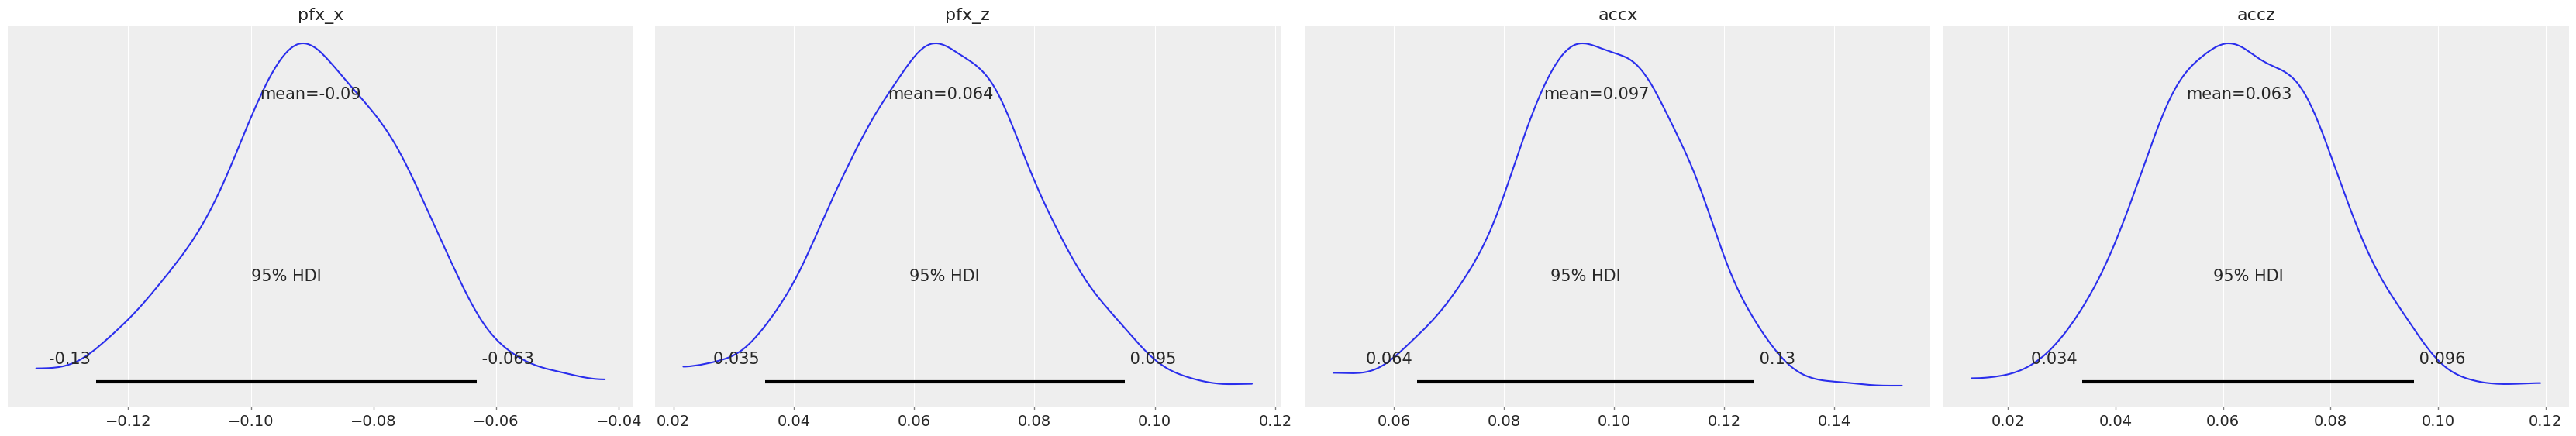

In [29]:
# do it again but just with impact variables
with pm.Model() as profile_1:
    # Priors
    intercept = pm.Normal("intercept", mu=0, sigma=10)
    pfx_x = pm.Normal("pfx_x", mu=0, sigma=10)
    pfx_z = pm.Normal("pfx_z", mu=0, sigma=10)
    accx = pm.Normal("accx", mu=0, sigma=10)
    accz = pm.Normal("accz", mu=0, sigma=10)


    # Likelihood
    mu = intercept + (pfx_x*df['pfx_x']) + (pfx_z*df['pfx_z']) + (accx*df['ax']) + (accz*df['az'])
    theta = pm.Deterministic('theta', pm.math.sigmoid(mu))
    y1 = pm.Bernoulli('y1', p=theta, observed=labels)

    # ELPD_LOO
    mean_field4_1 = pm.fit(method='advi', obj_optimizer=pm.adagrad_window(learning_rate=1e-2))
    # idata2 = pm.sample(draws=1000, idata_kwargs={"log_likelihood":True})
    # idata2.extend(pm.sample_posterior_predictive(idata2))
    # loocv_ump1["m2"] = idata2

trace_advi4_1 = mean_field4_1.sample(1000)

# add to model comparision dict
loocv_ump1["profile"] = trace_advi4_1

# Plot posterior
az.plot_posterior(trace_advi4_1, var_names=['pfx_x', 'pfx_z', 'accx', 'accz'], hdi_prob=0.95)

**Accuracy**

In [30]:
# Init param samples
param_samples = {}

# Make predictions for each posterior sample
n_samples = len(trace_profile.posterior['intercept']) # ****CHANGE TRACE (when copied and aplied to other model)
n_obs = len(df_test)

# Initialize predictions array
all_preds = np.zeros((n_samples, n_obs))

# Add intercept
param_samples['intercept'] = trace_profile.posterior['intercept'].values.flatten() # ****CHANGE TRACE (when copied and aplied to other model)

# Get samples from each param (generalized for any number of params)
for param in ['pfx_x', 'pfx_z', 'accx', 'accz']: # ****CHANGE PARAMS LIST (when copied and aplied to other model)
    param_samples[param] = trace_profile.posterior[param].values.flatten()  # ****CHANGE TRACE (when copied and aplied to other model)

# Make predictions
for i in range(n_samples):
  # Use df_test!
  # ****CHANGE MU PARAMS BEING USED (when copied and aplied to other model)
  mu = param_samples['intercept'][i] + (
      (param_samples['pfx_x'][i]*df_test['pfx_x']) + (param_samples['pfx_z'][i]*df_test['pfx_z'])
       + (param_samples['accx'][i]*df_test['ax']) + (param_samples['accz'][i]*df_test['az'])
  )
  all_preds[i, :] = 1 / (1 + np.exp(-mu))  # sigmoid function

# Make predictions
y_pred_proba = all_preds.mean(axis=0)
y_pred = (y_pred_proba > 0.5).astype(int)

# Calculate accuracy
accuracy = np.mean(y_pred == df_test['error_in_decision'])
model_accuracies["profile"] = accuracy    # ****CHANGE NAME OF MODEL KEY (when copied and aplied to other model)

# print accuracy
print(f"Accuracy: {accuracy}")
print(f"Number of Category 0: {np.sum(y_pred == 0)}")
print(f"Number of Category 1: {np.sum(y_pred == 1)}")

Accuracy: 0.8702772963604852
Number of Category 0: 11540
Number of Category 1: 0


# 5) Important Situation
- delta_home_win_exp, delta_run_exp, home_score, away_score, on_3b/2/1

**Check Priors**

<ipython-input-31-e8505904424a>:83: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


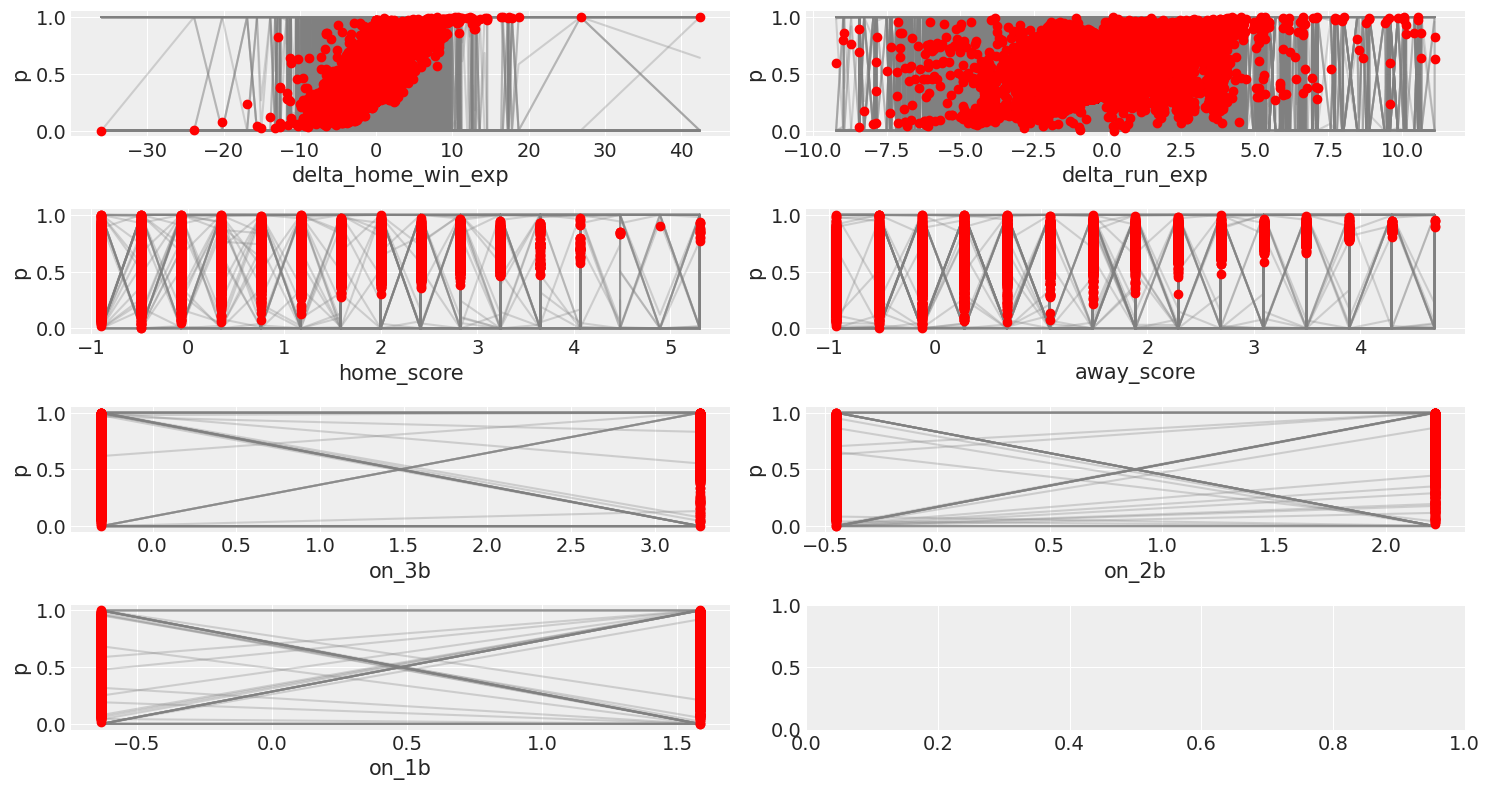

In [31]:
# Prior checking
# Create synthetic dataset
# ****CHNAGE THESE
t_intercept = 0
t_delta_home_win_exp = .25
t_delta_run_exp = .2
t_home_score = .2
t_away_score = 0.4
t_on_3b = .2
t_on_2b = .2
t_on_1b = .2

# ****CHANGE T_MU
t_mu = t_intercept + (
        (t_delta_home_win_exp*df['delta_home_win_exp']) + (t_delta_run_exp*df['delta_run_exp']) + (t_home_score*df['home_score']) +
        (t_away_score*df['away_score']) + (t_on_3b*df['on_3b']) + (t_on_2b*df['on_2b']) + (t_on_1b*df['on_1b'])
    )
true_p = 1 / (1+np.exp(-t_mu))
true_outcomes = np.array((true_p > 0.5).astype(int))


with pm.Model() as prior_check:

    # Priors
    intercept = pm.Normal("intercept", mu=0, sigma=10)  # ****CHANGE ALL PRIORS
    delta_home_win_exp = pm.Normal("delta_home_win_exp", mu=0, sigma=10)
    delta_run_exp = pm.Normal("delta_run_exp", mu=0, sigma=10)
    home_score = pm.Normal("home_score", mu=0, sigma=10)
    away_score = pm.Normal("away_score", mu=0, sigma=10)
    on_3b = pm.Normal("on_3b", mu=0, sigma=10)
    on_2b = pm.Normal("on_2b", mu=0, sigma=10)
    on_1b = pm.Normal("on_1b", mu=0, sigma=10)

    # Logistic transform
    # ****CHANGE MU
    mu = intercept + (
        (delta_home_win_exp*df['delta_home_win_exp']) + (delta_run_exp*df['delta_run_exp']) + (home_score*df['home_score']) +
        (away_score*df['away_score']) + (on_3b*df['on_3b']) + (on_2b*df['on_2b']) + (on_1b*df['on_1b'])
    )
    p = pm.Deterministic('p', pm.math.sigmoid(mu))

    # outcome
    outcome = pm.Bernoulli("outcome", p=p, observed=true_outcomes)

    idata = pm.sample_prior_predictive(draws=50, random_seed=42)




# Get the prior predictive probabilities (loop through each prior)
col = 0
row = 0
params = ["delta_home_win_exp", 'delta_run_exp', 'home_score', 'away_score', 'on_3b', 'on_2b', 'on_1b']  # ****CHANGE PARAMS
fig, axs = plt.subplots(ncols=2, nrows=(len(params)//2) + (len(params)%2), figsize=(15, 8))
p_prior = idata.prior["p"].values  # shape: (draws, obs)

for param in params:

  X_sorted_idx = np.argsort(df[param])
  X_sorted = df[param].values[X_sorted_idx]
  true_sorted = true_p.iloc[X_sorted_idx]

  for sig in p_prior[0]:
      # Sort data
      sig_sort = sig[X_sorted_idx]
      # Plot data
      axs[row, col].plot(X_sorted, sig_sort, color='gray', alpha=0.3)


  # plt.plot(X_sorted, p_prior_sorted[0][0], color='dodgerblue')

  axs[row, col].scatter(X_sorted, true_sorted, color='red', label='True Outcomes', zorder=3)

  axs[row, col].set_xlabel(param)
  axs[row, col].set_ylabel("p")
  # axs[row, col].legend()

  col += 1
  if col > 1:
    col = 0
    row += 1

plt.tight_layout()
plt.show()

**Create Model**

Output()

array([[<Axes: title={'center': 'delta_home_win_exp'}>,
        <Axes: title={'center': 'delta_run_exp'}>,
        <Axes: title={'center': 'home_score'}>],
       [<Axes: title={'center': 'away_score'}>,
        <Axes: title={'center': 'on_3b'}>,
        <Axes: title={'center': 'on_2b'}>],
       [<Axes: title={'center': 'on_1b'}>, <Axes: >, <Axes: >]],
      dtype=object)

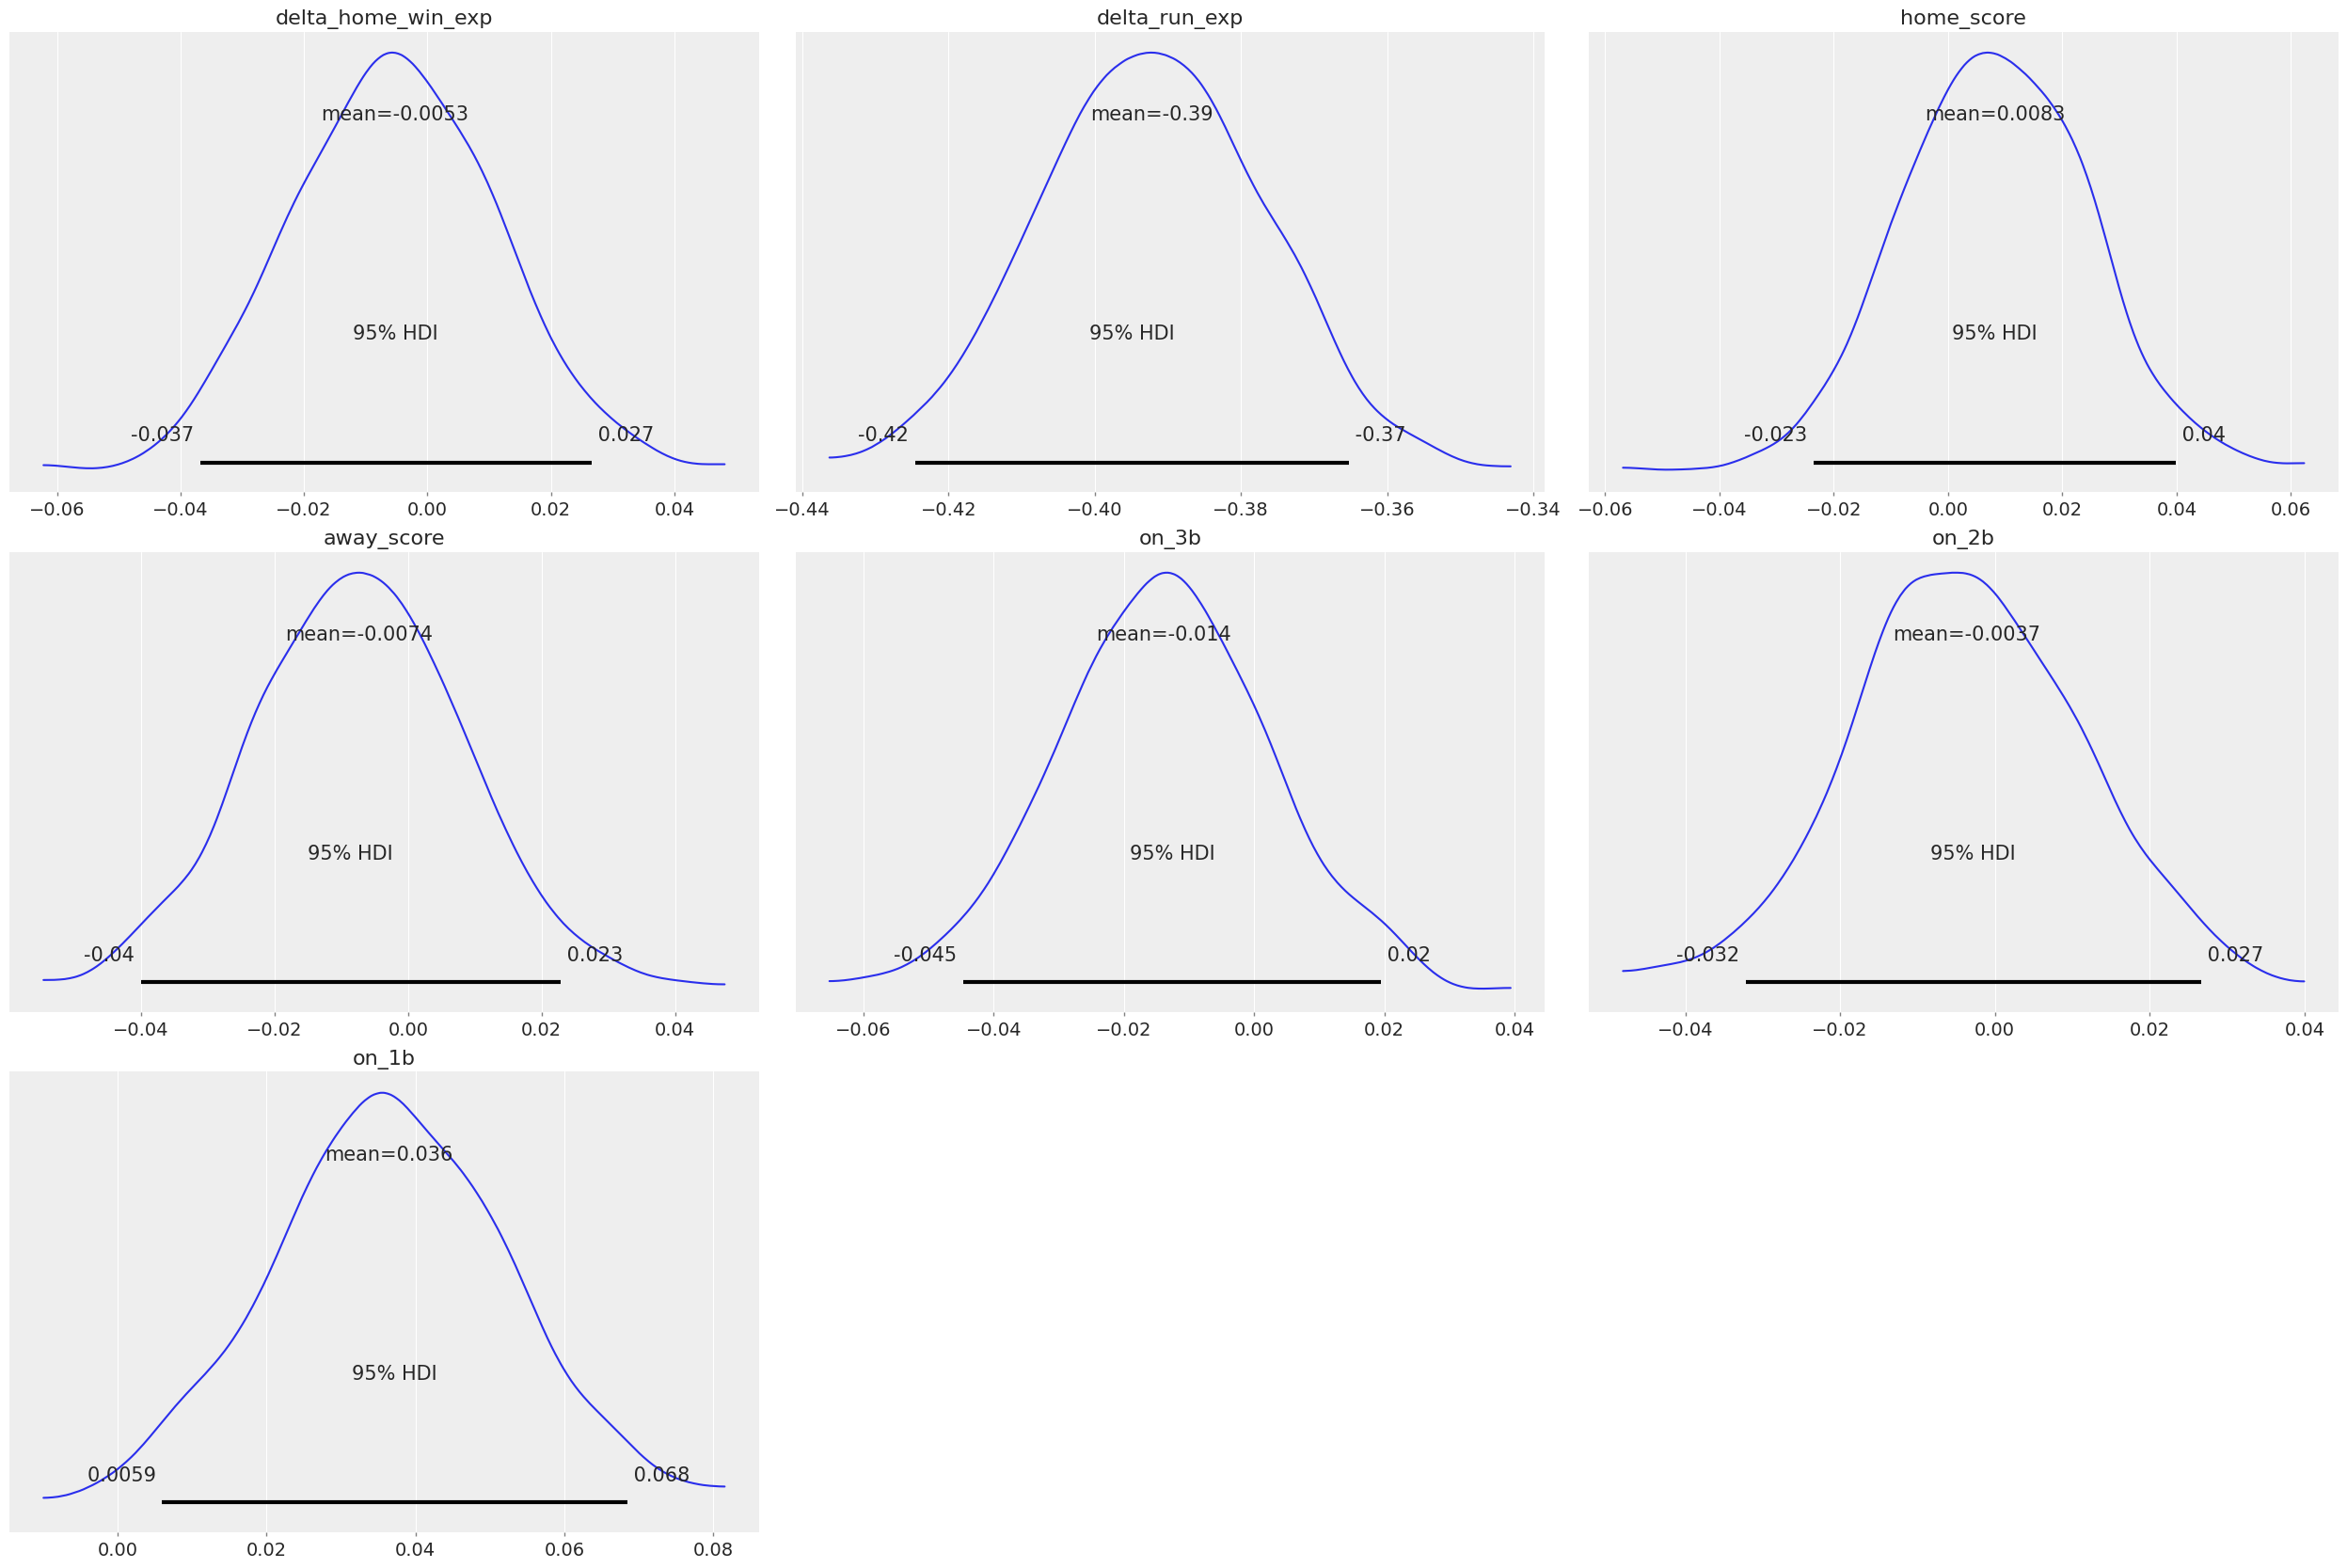

In [32]:
# imp sit model
with pm.Model() as situation:
    # Priors
    intercept = pm.Normal("intercept", mu=0, sigma=10)
    delta_home_win_exp = pm.Normal("delta_home_win_exp", mu=0, sigma=10)
    delta_run_exp = pm.Normal("delta_run_exp", mu=0, sigma=10)
    home_score = pm.Normal("home_score", mu=0, sigma=10)
    away_score = pm.Normal("away_score", mu=0, sigma=10)
    on_3b = pm.Normal("on_3b", mu=0, sigma=10)
    on_2b = pm.Normal("on_2b", mu=0, sigma=10)
    on_1b = pm.Normal("on_1b", mu=0, sigma=10)

    # Likelihood
    mu = intercept + (
        (delta_home_win_exp*df['delta_home_win_exp']) + (delta_run_exp*df['delta_run_exp']) + (home_score*df['home_score']) +
        (away_score*df['away_score']) + (on_3b*df['on_3b']) + (on_2b*df['on_2b']) + (on_1b*df['on_1b'])
    )
    theta = pm.Deterministic('theta', pm.math.sigmoid(mu))
    y1 = pm.Bernoulli('y1', p=theta, observed=labels)

    # ELPD_LOO
    mean_field6 = pm.fit(method='advi', obj_optimizer=pm.adagrad_window(learning_rate=1e-2))
    # idata2 = pm.sample(draws=1000, idata_kwargs={"log_likelihood":True})
    # idata2.extend(pm.sample_posterior_predictive(idata2))
    # loocv_ump1["m2"] = idata2

trace_situation = mean_field6.sample(1000)

# add to model comparision dict
loocv_ump1["situation"] = trace_situation

az.plot_posterior(trace_situation, var_names=["delta_home_win_exp", 'delta_run_exp', 'home_score', 'away_score', 'on_3b', 'on_2b', 'on_1b'], hdi_prob=0.95)

**Accuracy**

In [33]:
# Init param samples
param_samples = {}

# Make predictions for each posterior sample
n_samples = len(trace_situation.posterior['intercept']) # ****CHANGE TRACE (when copied and aplied to other model)
n_obs = len(df_test)

# Initialize predictions array
all_preds = np.zeros((n_samples, n_obs))

# Add intercept
param_samples['intercept'] = trace_situation.posterior['intercept'].values.flatten() # ****CHANGE TRACE (when copied and aplied to other model)

# Get samples from each param (generalized for any number of params)
for param in ["delta_home_win_exp", 'delta_run_exp', 'home_score', 'away_score', 'on_3b', 'on_2b', 'on_1b']: # ****CHANGE PARAMS LIST (when copied and aplied to other model)
    param_samples[param] = trace_situation.posterior[param].values.flatten()  # ****CHANGE TRACE (when copied and aplied to other model)

# Make predictions
for i in range(n_samples):
  # Use df_test!
  # ****CHANGE MU PARAMS BEING USED (when copied and aplied to other model)
  mu = param_samples['intercept'][i] + (
      (param_samples['delta_home_win_exp'][i]*df_test['delta_home_win_exp']) + (param_samples['delta_run_exp'][i]*df_test['delta_run_exp'])
       + (param_samples['home_score'][i]*df_test['home_score']) + (param_samples['away_score'][i]*df_test['away_score'])
       + (param_samples['on_3b'][i]*df_test['on_3b']) + (param_samples['on_2b'][i]*df_test['on_2b']) + (param_samples['on_1b'][i]*df_test['on_1b'])
  )
  all_preds[i, :] = 1 / (1 + np.exp(-mu))  # sigmoid function

# Make predictions
y_pred_proba = all_preds.mean(axis=0)
y_pred = (y_pred_proba > 0.5).astype(int)

# Calculate accuracy
accuracy = np.mean(y_pred == df_test['error_in_decision'])
model_accuracies["profile"] = accuracy    # ****CHANGE NAME OF MODEL KEY (when copied and aplied to other model)

# print accuracy
print(f"Accuracy: {accuracy}")
print(f"Number of Category 0: {np.sum(y_pred == 0)}")
print(f"Number of Category 1: {np.sum(y_pred == 1)}")

Accuracy: 0.869844020797227
Number of Category 0: 11517
Number of Category 1: 23


# 6) Dimentions of pitcher and hitter
- all_star_player, sz_bot, sz_top, stand, p_throws, stand

**Check Priors**

<ipython-input-34-568324b67086>:79: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


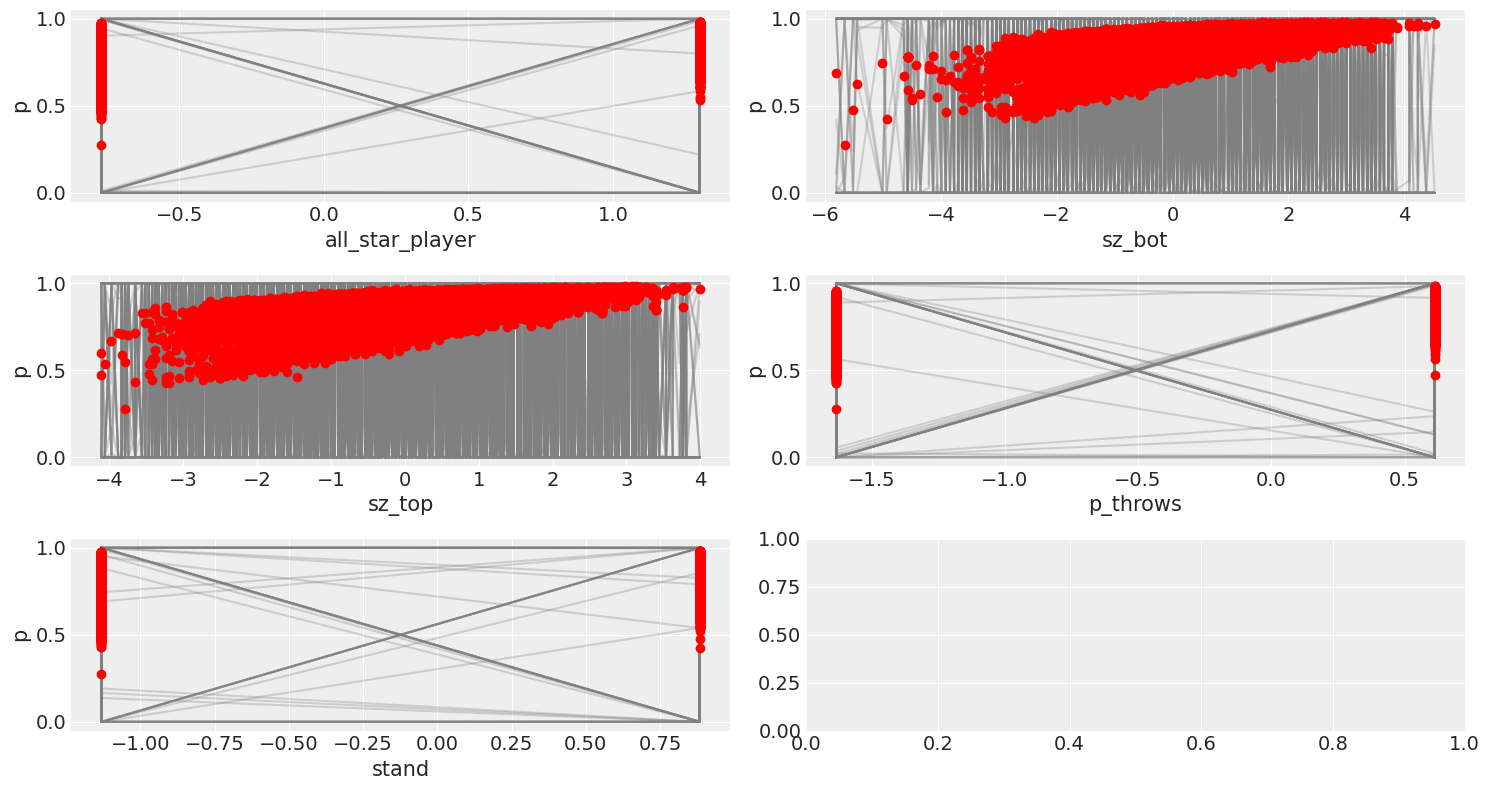

In [34]:
# Prior checking
# Create synthetic dataset
# ****CHNAGE THESE
t_intercept = 2
t_all_star_player = .25
t_sz_bot = .2
t_sz_top = .2
t_p_throws = 0.4
t_stand = .2

# ****CHANGE T_MU
t_mu = t_intercept + (
        (t_all_star_player*df['all_star_player']) + (t_sz_bot*df['sz_bot']) + (t_sz_top*df['sz_top'])
        + (t_p_throws*df['p_throws']) + (t_stand*df['stand'])
    )
true_p = 1 / (1+np.exp(-t_mu))
true_outcomes = np.array((true_p > 0.5).astype(int))


with pm.Model() as prior_check:

    # Priors
    intercept = pm.Normal("intercept", mu=0, sigma=10)  # ****CHANGE ALL PRIORS
    all_star_player = pm.Normal("all_star_player", mu=0, sigma=10)
    sz_bot = pm.Normal("sz_bot", mu=0, sigma=10)
    sz_top = pm.Normal("sz_top", mu=0, sigma=10)
    p_throws = pm.Normal("p_throws", mu=0, sigma=10)
    stand = pm.Normal("stand", mu=0, sigma=10)

    # Logistic transform
    # ****CHANGE MU
    mu = intercept + (
        (all_star_player*df['all_star_player']) + (sz_bot*df['sz_bot']) + (sz_top*df['sz_top'])
        + (p_throws*df['p_throws']) + (stand*df['stand'])
    )
    p = pm.Deterministic('p', pm.math.sigmoid(-mu))

    # outcome
    outcome = pm.Bernoulli("outcome", p=p, observed=true_outcomes)

    idata = pm.sample_prior_predictive(draws=50, random_seed=42)




# Get the prior predictive probabilities (loop through each prior)
col = 0
row = 0
params = ['all_star_player', 'sz_bot', 'sz_top', 'p_throws', 'stand']  # ****CHANGE PARAMS
fig, axs = plt.subplots(ncols=2, nrows=(len(params)//2) + (len(params)%2), figsize=(15, 8))
p_prior = idata.prior["p"].values  # shape: (draws, obs)

for param in params:

  X_sorted_idx = np.argsort(df[param])
  X_sorted = df[param].values[X_sorted_idx]
  true_sorted = true_p.iloc[X_sorted_idx]

  for sig in p_prior[0]:
      # Sort data
      sig_sort = sig[X_sorted_idx]
      # Plot data
      axs[row, col].plot(X_sorted, sig_sort, color='gray', alpha=0.3)


  # plt.plot(X_sorted, p_prior_sorted[0][0], color='dodgerblue')

  axs[row, col].scatter(X_sorted, true_sorted, color='red', label='True Outcomes', zorder=3)

  axs[row, col].set_xlabel(param)
  axs[row, col].set_ylabel("p")
  # axs[row, col].legend()

  col += 1
  if col > 1:
    col = 0
    row += 1

plt.tight_layout()
plt.show()

**Create Model**

Output()

array([[<Axes: title={'center': 'all_star_player'}>,
        <Axes: title={'center': 'sz_bot'}>,
        <Axes: title={'center': 'sz_top'}>],
       [<Axes: title={'center': 'p_throws'}>,
        <Axes: title={'center': 'stand'}>, <Axes: >]], dtype=object)

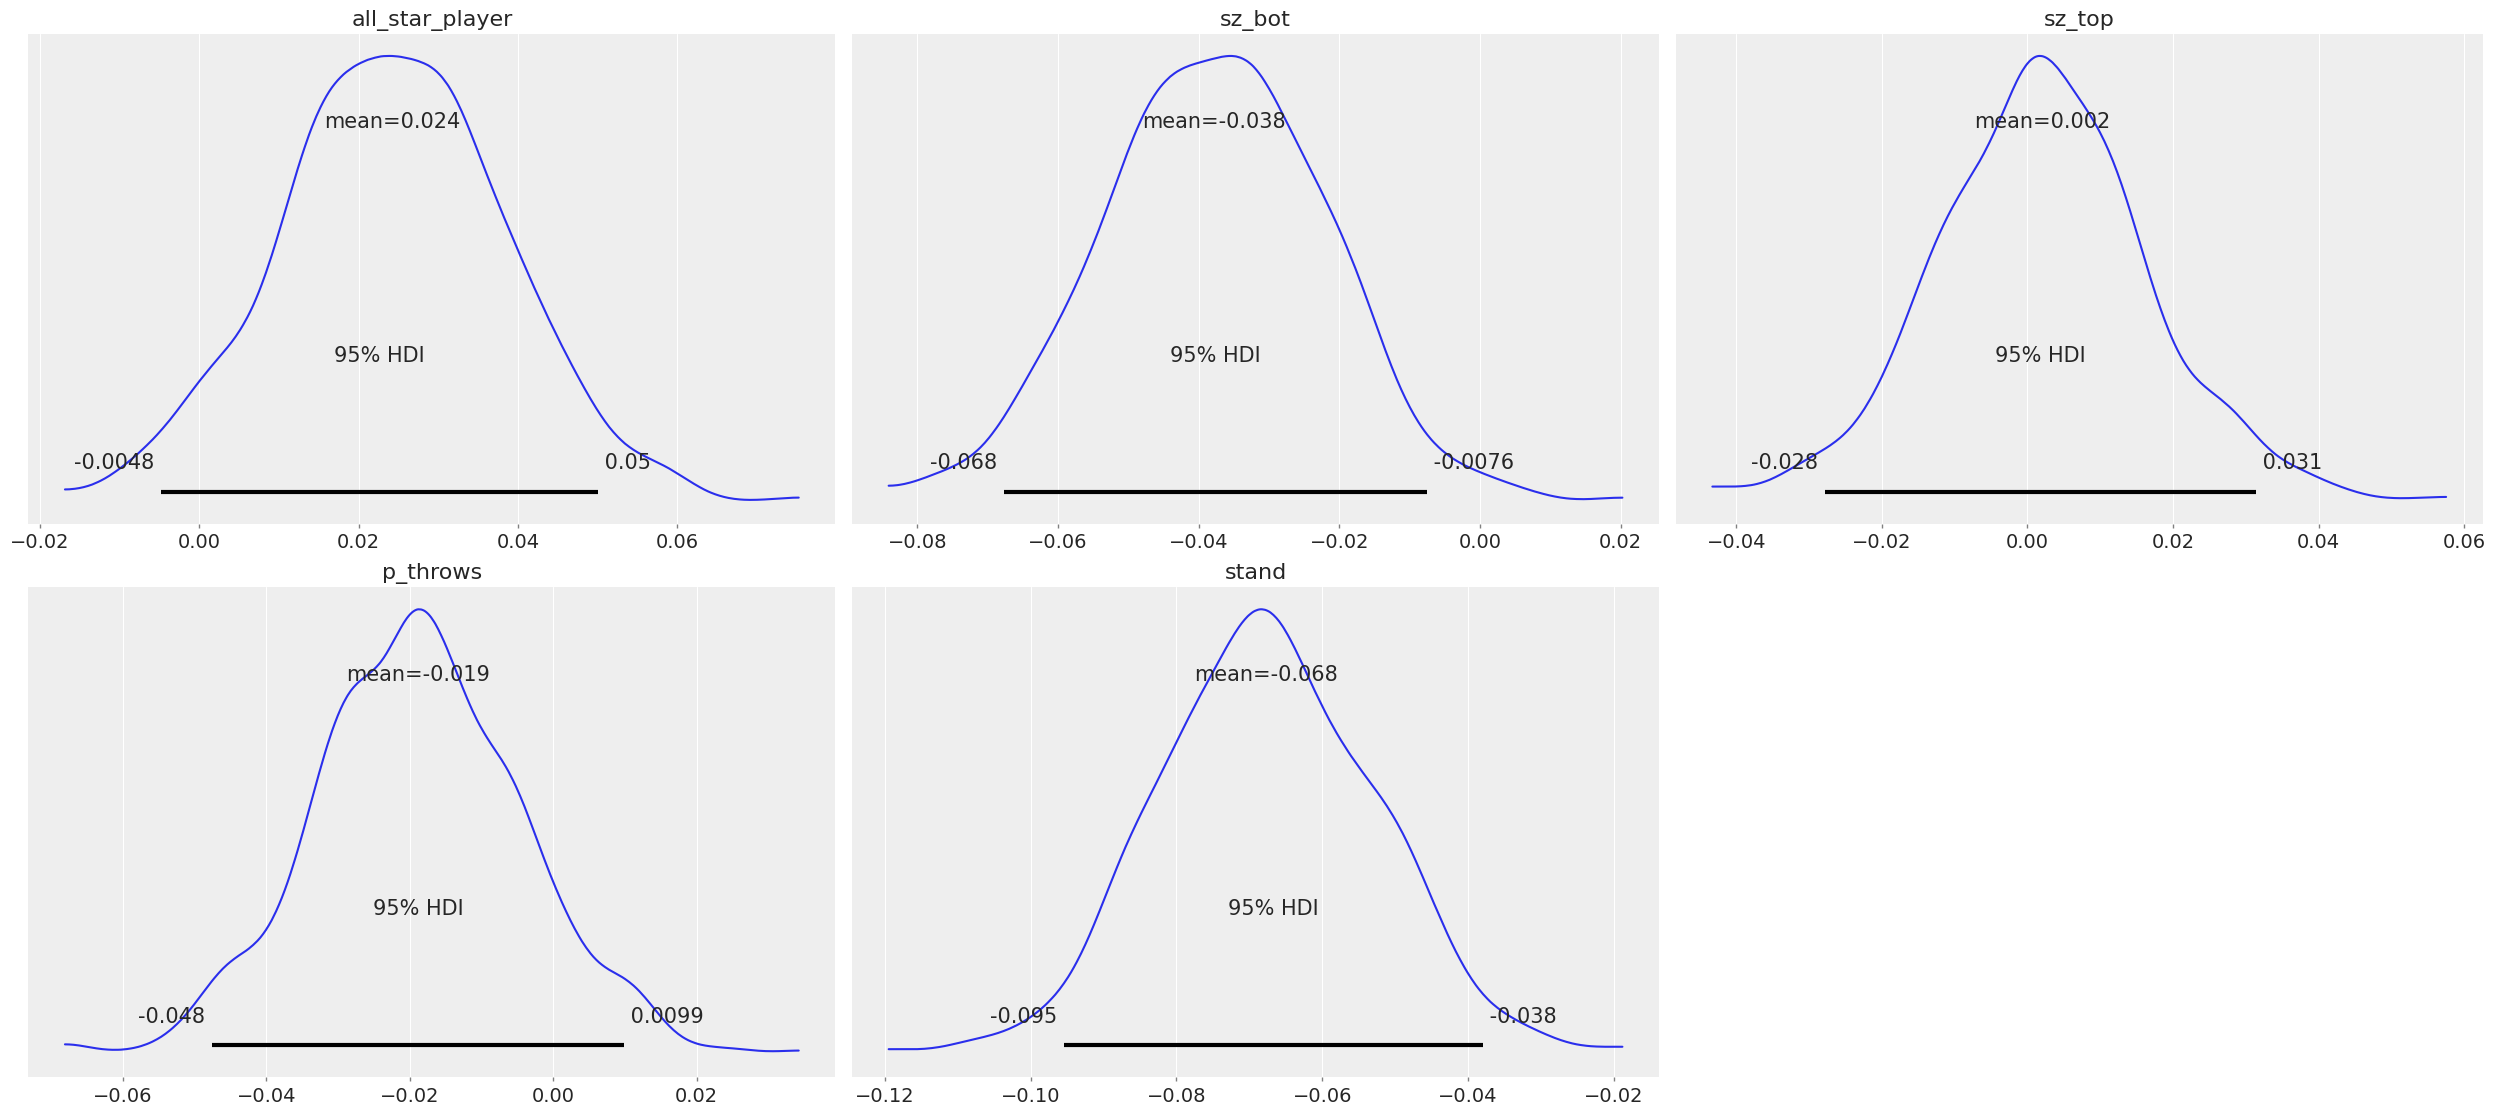

In [35]:
# player dimentions model
with pm.Model() as dimentions:
    # Priors
    intercept = pm.Normal("intercept", mu=0, sigma=10)
    all_star_player = pm.Normal("all_star_player", mu=0, sigma=10)
    sz_bot = pm.Normal("sz_bot", mu=0, sigma=10)
    sz_top = pm.Normal("sz_top", mu=0, sigma=10)
    p_throws = pm.Normal("p_throws", mu=0, sigma=10)
    stand = pm.Normal("stand", mu=0, sigma=10)

    # Likelihood
    mu = intercept + (all_star_player*df['all_star_player']) + (sz_bot*df['sz_bot']) + (sz_top*df['sz_top']) + (p_throws*df['p_throws']) + (stand*df['stand'])
    theta = pm.Deterministic('theta', pm.math.sigmoid(mu))
    y1 = pm.Bernoulli('y1', p=theta, observed=labels)

    # ELPD_LOO
    mean_field6 = pm.fit(method='advi', obj_optimizer=pm.adagrad_window(learning_rate=1e-2))
    # idata2 = pm.sample(draws=1000, idata_kwargs={"log_likelihood":True})
    # idata2.extend(pm.sample_posterior_predictive(idata2))
    # loocv_ump1["m2"] = idata2

trace_dimentions = mean_field6.sample(1000)

# add to model comparision dict
loocv_ump1["dimentions"] = trace_dimentions

az.plot_posterior(trace_dimentions, var_names=['all_star_player', 'sz_bot', 'sz_top', 'p_throws', 'stand'], hdi_prob=0.95)

**Accuracy**

In [39]:
# Init param samples
param_samples = {}

# Make predictions for each posterior sample
n_samples = len(trace_dimentions.posterior['intercept']) # ****CHANGE TRACE (when copied and aplied to other model)
n_obs = len(df_test)

# Initialize predictions array
all_preds = np.zeros((n_samples, n_obs))

# Add intercept
param_samples['intercept'] = trace_dimentions.posterior['intercept'].values.flatten() # ****CHANGE TRACE (when copied and aplied to other model)

# Get samples from each param (generalized for any number of params)
for param in ['all_star_player', 'sz_bot', 'sz_top', 'p_throws', 'stand']: # ****CHANGE PARAMS LIST (when copied and aplied to other model)
    param_samples[param] = trace_dimentions.posterior[param].values.flatten()  # ****CHANGE TRACE (when copied and aplied to other model)

# Make predictions
for i in range(n_samples):
  # Use df_test!
  # ****CHANGE MU PARAMS BEING USED (when copied and aplied to other model)
  mu = param_samples['intercept'][i] + (
      (param_samples['all_star_player'][i]*df_test['all_star_player']) + (param_samples['sz_bot'][i]*df_test['sz_bot'])
       + (param_samples['sz_top'][i]*df_test['sz_top']) + (param_samples['p_throws'][i]*df_test['p_throws'])
       + (param_samples['stand'][i]*df_test['stand'])
  )
  all_preds[i, :] = 1 / (1 + np.exp(-mu))  # sigmoid function

# Make predictions
y_pred_proba = all_preds.mean(axis=0)
y_pred = (y_pred_proba > 0.5).astype(int)

# Calculate accuracy
accuracy = np.mean(y_pred == df_test['error_in_decision'])
model_accuracies["dimentions"] = accuracy    # ****CHANGE NAME OF MODEL KEY (when copied and aplied to other model)

# print accuracy
print(f"Accuracy: {accuracy}")
print(f"Number of Category 0: {np.sum(y_pred == 0)}")
print(f"Number of Category 1: {np.sum(y_pred == 1)}")

Accuracy: 0.8702772963604852
Number of Category 0: 11540
Number of Category 1: 0


# Compare Models

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'location'),
  Text(1, 0, 'pitch_type'),
  Text(2, 0, 'count'),
  Text(3, 0, 'pitch_characteristics'),
  Text(4, 0, 'profile'),
  Text(5, 0, 'dimentions')])

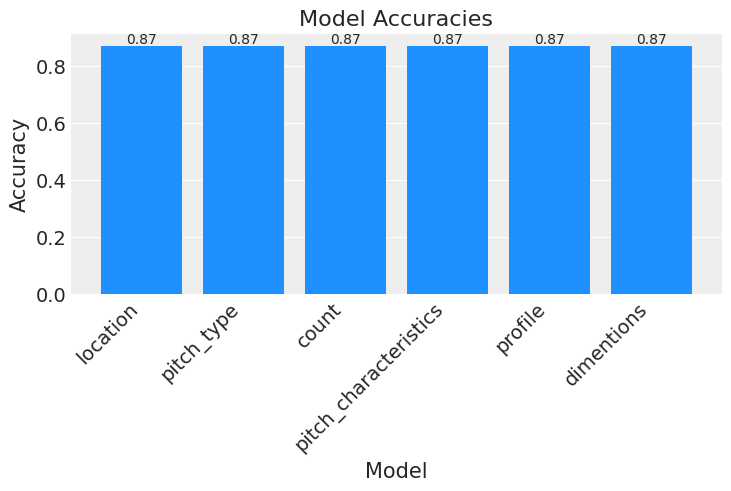

In [40]:
# ELPD_loo is not working at the moment, working to figure it out
# in the mean time, I'm using a test set to compute accruacy, this is plotted in the bar chart
# cmp = az.compare(loocv_ump1)
# az.plot_compare(cmp, figsize=(20, 9))
# plt.savefig('model_comparison.svg')

# Bar chart
import matplotlib.pyplot as plt

# Extract model names and accuracies
model_names = list(model_accuracies.keys())
accuracies = list(model_accuracies.values())

# Create bar chart
plt.bar(model_names, accuracies, color='dodgerblue')

# Add values on top of bars
for i, v in enumerate(accuracies):
    plt.text(i, v, str(round(v, 2)), ha='center', va='bottom')

# Customize chart
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Accuracies")
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability